## Block 1 — Environment Initialization & Spark Configuration*

**Rationale:**
This block establishes the compute foundation by mounting persistent storage for datasets and model checkpoints, while configuring the **SparkSession** to prevent resource exhaustion during complex join operations or iterative feature extraction tasks.

**Technical Implementation:**
We install a specialized dependency stack including **PySpark** for scalable ETL, **LangGraph** for multi-agent workflows, and **imbalanced-learn** to address class distribution skews typical in recommendation labels. We intentionally lower `spark.sql.shuffle.partitions` to **16** to reduce the overhead of small-task scheduling within the single-node Colab environment, ensuring significantly faster data shuffling compared to the default 200 partitions.

In [ ]:
!pip install -q pyspark langgraph langchain_openai imbalanced-learn
from google.colab import drive
import os
import sys
from pyspark.sql import SparkSession

drive.mount('/content/drive')
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

spark = (
    SparkSession.builder
    .appName("BT4221_Hybrid_Recommender")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.memory.fraction", "0.7")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")

Mounted at /content/drive
Spark version: 4.0.2


## Block 2 — Data Ingestion & Quality Filtering*

**Rationale:**
This block consolidates the previously partitioned CSV chunks into a single DataFrame to prepare for downstream modeling. Since the raw data includes LLM-extracted features and free-text reviews, strict validation is required to remove malformed records, extraction errors, or incomplete interactions that would degrade recommender performance.

**Technical Implementation:**
We load the six partitions using `spark.read` with `multiLine` and `escape` options enabled to correctly parse complex text strings containing line breaks or quotes. The pipeline utilizes **predicate pushdown** by filtering `clean_trope` errors and dropping nulls across core dimensions (`reviewerID`, `bookID`, `overall`) early in the execution DAG. This ensures the Spark engine only processes high-signal rows, minimizing memory overhead for subsequent transformations.

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType

base_path = "/content/drive/MyDrive/BT4221/"
paths = [f"{base_path}output_features_{i}.csv" for i in range(1, 7)]

# Leverage predicate pushdown to filter invalid records early in the DAG execution
df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .csv(paths)
    .filter(F.col("clean_trope").isNotNull())
    .filter(F.col("clean_trope") != "Invalid/Failed")
    .filter(~F.col("clean_trope").startswith("Error:"))
    .dropna(subset=["reviewText", "overall", "reviewerID", "bookID"])
    # .filter(F.length(F.trim(F.col("reviewText"))) > 10)
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- reviewerID: string (nullable = true)
 |-- bookID: string (nullable = true)
 |-- helpful: string (nullable = true)
 |-- overall: integer (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- reviewTime: string (nullable = true)
 |-- clean_trope: string (nullable = true)
 |-- genres: string (nullable = true)

+---------------------+----------+-------+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 3 — Genre Feature Vectorization*

**Rationale:**
Machine learning algorithms require numerical inputs rather than raw strings. Since books often belong to multiple categories, we must transform the comma-separated "genres" column into a structured format that captures category membership without inflating the dataset’s dimensionality unnecessarily.

**Technical Implementation:**
We first preprocess the string data into an array type using **`F.split`** with a regex pattern to handle inconsistent spacing. We then apply **`CountVectorizer`**, which builds a vocabulary of all unique genres across the dataset and encodes each row as a **sparse vector**. This approach is computationally superior to traditional one-hot encoding as it stores only non-zero indices, significantly reducing the memory footprint during the subsequent model training phase.

In [ ]:
import pyspark.sql.functions as F
from pyspark.ml.feature import CountVectorizer

# Convert the 'genres' string column to an array of strings, handling nulls
df = df.withColumn("genres_array",
    F.when(
        F.col("genres").isNull(), F.array()
    ).otherwise(
        F.split(F.col("genres"), ",\\s*")
    )
)

cv_genre = CountVectorizer(inputCol="genres_array", outputCol="genre_vector")
model = cv_genre.fit(df)
df = model.transform(df)
df.show(truncate=False)

+---------------------+----------+-------+-------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 4 — Temporal Train-Test Splitting*

**Rationale:**
In recommendation systems, a random split leads to "data leakage" by using a user's future interactions to predict past behavior. To evaluate the model's predictive power realistically, we apply a chronological split. This ensures the training set contains a user's historical preferences, while the test set contains their subsequent "future" actions, simulating a real-world deployment scenario.

**Technical Implementation:**
We define two **Window** partitions partitioned by `reviewerID`. The first ranks reviews by `reviewTime` to establish chronological order, while the second calculates the total interaction count per user. By comparing `temporal_rank` against `total_reviews`, we execute a per-user **80/20 split**. This approach is computationally efficient in Spark as it avoids a full dataset shuffle, instead localized within the partition boundaries of each user.

In [ ]:
from pyspark.sql.window import Window

user_rank_window = Window.partitionBy("reviewerID").orderBy(F.col("reviewTime"))
user_count_window = Window.partitionBy("reviewerID")

# Materialize partition boundaries to prevent logical plan re-evaluation
df_ranked = df \
    .withColumn("temporal_rank", F.row_number().over(user_rank_window)) \
    .withColumn("total_reviews", F.count("*").over(user_count_window))

df_train = df_ranked.filter(F.col("temporal_rank") <= (F.col("total_reviews") * 0.8).cast("int")).drop("temporal_rank", "total_reviews")
df_test = df_ranked.filter(F.col("temporal_rank") > (F.col("total_reviews") * 0.8).cast("int")).drop("temporal_rank", "total_reviews")

train_count = df_train.count()
test_count = df_test.count()

print(f"Training rows : {train_count:,}")
print(f"Test rows     : {test_count:,}")

# Calculate sparsity of the training set
unique_users_train = df_train.select("reviewerID").distinct().count()
unique_books_train = df_train.select("bookID").distinct().count()
total_possible_interactions = unique_users_train * unique_books_train
actual_interactions = train_count

sparsity = 1 - (actual_interactions / total_possible_interactions)
density = (actual_interactions / total_possible_interactions)

print(f"\n--- Training Set Sparsity ---")
print(f"Unique users in training set: {unique_users_train:,}")
print(f"Unique books in training set: {unique_books_train:,}")
print(f"Total possible interactions: {total_possible_interactions:,}")
print(f"Actual interactions: {actual_interactions:,}")
print(f"Sparsity: {sparsity:.4f}")
print(f"Density: {density:.4f}")

Training rows : 53,711
Test rows     : 15,613

--- Training Set Sparsity ---
Unique users in training set: 4,429
Unique books in training set: 2,474
Total possible interactions: 10,957,346
Actual interactions: 53,711
Sparsity: 0.9951
Density: 0.0049


## Block 5 — Ground Truth Construction*

**Rationale:**
To evaluate the recommender's performance using metrics like Recall@K or NDCG, we must establish a "gold standard" from the test set. By isolating the items a user actually liked (top-rated), we create a target list that the model's predictions will be measured against.

**Technical Implementation:**
We apply a **Window function** to rank books for each user in the test set, ordered by their `overall` rating in descending order. We filter for the **top 50 items** per user and use `F.collect_list` to aggregate these IDs into a single ground-truth array (`gt_list`). The resulting DataFrame is **cached** to memory, ensuring that this evaluation baseline remains instantly accessible and does not require re-computation during the iterative model testing phase.

In [ ]:
# Get Ground Truth (top rated items per user in test set)
window_gt = Window.partitionBy("reviewerID").orderBy(F.col("overall").desc())
gt_df = df_test.withColumn("rank", F.row_number().over(window_gt)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("bookID").alias("gt_list"))

gt_df.cache()

gt_df.show(5, truncate=False)

+--------------------+------------------------------------------------------------+
|reviewerID          |gt_list                                                     |
+--------------------+------------------------------------------------------------+
|A0099735VDZ3HDCAAYKL|[B001HQHCBQ, B00JHNAWQS, B00JJY2XX0, B00K644CGI, B00KIXIBYQ]|
|A116UDTYVZUW2Z      |[B00FIL6SRA, B00C2RVRHE, B007JE1B1C, B00820YRF4]            |
|A11LLWNATMHTZP      |[B00KTI9R6Q, B00LZ4D0UC, B00K0OL35W]                        |
|A12NWV26GSNYZC      |[B00LBEQ3BY, B00KPIPQJ2]                                    |
|A12O5K3EQ4MC7Z      |[B00HVKCMQC, B00J6DKWSM, B00IDPG1SO, B00AZ7YSFQ, B009F19JFM]|
+--------------------+------------------------------------------------------------+
only showing top 5 rows


## Block 6 — TF-IDF Feature Pipeline*

**Rationale:**
To capture the nuanced semantic information in user tropes, we must convert unstructured text into a weighted numerical representation. By combining these text-derived features with our existing categorical genre vectors, we create a unified feature space that allows the recommender to represent each book as a high-dimensional point, facilitating more accurate similarity and preference modeling.

**Technical Implementation:**
We utilize a **Spark ML Pipeline** to chain multiple transformations sequentially. The trope data undergoes **Tokenization** and **StopWordsRemoval**, followed by **HashingTF** to map tokens to a fixed 512-dimensional space. We then apply **IDF (Inverse Document Frequency)** to down-weight common tropes and highlight unique, high-signal terms. Finally, **VectorAssembler** concatenates these TF-IDF trope vectors with the previously computed `genre_vector`, producing a consolidated `tfidf_features` vector that serves as the primary input for our recommendation algorithms.

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, CountVectorizer, VectorAssembler
from pyspark.ml import Pipeline

tok_trope = Tokenizer(inputCol="clean_trope", outputCol="words_trope")
sw_trope = StopWordsRemover(inputCol="words_trope", outputCol="filtered_trope")
htf_trope = HashingTF(inputCol="filtered_trope", outputCol="tf_trope", numFeatures=512)
idf_trope = IDF(inputCol="tf_trope", outputCol="tfidf_trope", minDocFreq=2)

assembler = VectorAssembler(
    inputCols=["tfidf_trope", "genre_vector"],
    outputCol="tfidf_features"
)

pipeline = Pipeline(stages=[tok_trope, sw_trope, htf_trope, idf_trope, assembler])

# Fit and Transform
model = pipeline.fit(df_train)
df_train = model.transform(df_train)

df_train.show()

+--------------------+----------+-------+-------+--------------------+----------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|          reviewerID|    bookID|helpful|overall|          reviewText|reviewTime|         clean_trope|              genres|        genres_array|        genre_vector|         words_trope|      filtered_trope|            tf_trope|         tfidf_trope|      tfidf_features|
+--------------------+----------+-------+-------+--------------------+----------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|A0099735VDZ3HDCAAYKL|B008XOWVVG| [1, 1]|      5|It was a good boo...|2013-01-31|A compelling love...|Romance, Contempo...|[Romance, Contemp...|(596,[0,1],[1.0,1...|[a, compelling, l...|[

## Block 7 — Word2vec Feature Pipeline*

**Rationale:**
While TF-IDF identifies key terms based on frequency, it fails to capture the latent semantic relationships between tropes (e.g., "haunted" and "ghostly"). By using **Word2Vec**, we project tropes into a continuous high-dimensional vector space where semantically similar concepts reside in close proximity. This ensures the recommender can recognize thematic overlaps even when specific keywords vary across different reviews.

**Technical Implementation:**
We train a **Word2Vec** model with a **vector size of 512**, mapping tokenized trope sequences to dense embeddings. Unlike the sparse vectors produced by TF-IDF, these dense representations encapsulate the context and meaning of the tropes. Finally, a **VectorAssembler** consolidates these semantic embeddings with the `genre_vector` into a unified `word2vec_features` column, providing a feature set that balances categorical structure with thematic nuance.

In [ ]:
from pyspark.ml.feature import Word2Vec

word2vec = Word2Vec(vectorSize=512, inputCol="words_trope", outputCol="trope_w2v")

w2v_model = word2vec.fit(df_train)
df_train = w2v_model.transform(df_train)


assembler_w2v = VectorAssembler(
    inputCols=["trope_w2v", "genre_vector"],
    outputCol="word2vec_features"
)

df_train = assembler_w2v.transform(df_train)
df_train.select("word2vec_features").show()

+--------------------+
|   word2vec_features|
+--------------------+
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
|(1108,[0,1,2,3,4,...|
+--------------------+
only showing top 20 rows


In [ ]:
df_train.printSchema()
df_test.printSchema()

root
 |-- reviewerID: string (nullable = true)
 |-- bookID: string (nullable = true)
 |-- helpful: string (nullable = true)
 |-- overall: integer (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- reviewTime: string (nullable = true)
 |-- clean_trope: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- genres_array: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- genre_vector: vector (nullable = true)
 |-- words_trope: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_trope: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- tf_trope: vector (nullable = true)
 |-- tfidf_trope: vector (nullable = true)
 |-- tfidf_features: vector (nullable = true)
 |-- trope_w2v: vector (nullable = true)
 |-- word2vec_features: vector (nullable = true)

root
 |-- reviewerID: string (nullable = true)
 |-- bookID: string (nullable = true)
 |-- helpful: string (nullable = true)
 |-- ove

## Block 8 — Evaluation Metric Definitions*

**Rationale:**
Standard regression metrics like RMSE are often insufficient for top-N recommendation tasks. To assess the model's performance, we utilize **Recall@K** to measure retrieval coverage and **NDCG@K** to evaluate ranking precision. These metrics ensure the model is not only identifying relevant items but also prioritizing them effectively in the top-K slots presented to the user.

**Technical Implementation:**
We define custom **PySpark UDFs** to parallelize the evaluation logic across the distributed dataset. `calculate_recall` determines the proportion of ground-truth items successfully captured within the top $K$ results. `calculate_ndcg` applies a logarithmic decay to reward the model for placing relevant items at the top of the list, normalizing the score against the **Ideal DCG (IDCG)** to ensure the metric remains comparable across users with different ground-truth sizes.

In [ ]:
import pyspark.sql.functions as F
@F.udf(returnType=DoubleType())
def calculate_recall(rec, gt, k):
    if not rec or not gt: return 0.0
    rec_k = set(rec[:k])
    gt_set = set(gt)
    hits = len(rec_k.intersection(gt_set))
    return float(hits / len(gt_set))

@F.udf(returnType=DoubleType())
def calculate_ndcg(rec, gt, k):
    import math
    if not rec or not gt:
        return 0.0
    rec_k = rec[:k]
    gt_set = set(gt)
    dcg = 0.0
    for i, item in enumerate(rec_k):
        if item in gt_set:
            dcg += 1.0 / math.log2(i + 2)
    actual_hits_possible = min(len(gt_set), k)
    if actual_hits_possible == 0:
        return 0.0
    idcg = sum([1.0 / math.log2(i + 2) for i in range(actual_hits_possible)])
    return float(dcg / idcg)

## Block 9 — Baseline on Full Reviews

**Rationale:**
This block transitions from individual reviews to a stable recommendation model by aggregating textual sentiment into high-dimensional profiles. By "mean pooling" review features, we represent books by their collective reception and users by their historical "positive" preferences. This content-based approach allows us to recommend items based on semantic and thematic alignment, effectively addressing the cold-start problem for items with sparse interaction data.

**Technical Implementation:**
We expand the **HashingTF** feature space to **2048 dimensions** to capture the increased complexity of raw `reviewText` compared to tropes. **Book profiles** are materialized by averaging vectors across all reviews, while **User profiles** are restricted to reviews with an `overall` rating of **$\ge 4$** to isolate positive affinity. We execute a **broadcasted cross-join** for similarity scoring, utilizing Spark’s `aggregate` and `zip_with` functions to compute distributed dot-products on normalized vectors. The resulting top-50 recommendations are then evaluated across multiple $K$ thresholds ($5, 10, 20, 50$) to measure ranking precision and retrieval coverage.

In [ ]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.stat import Summarizer
import pyspark.sql.functions as F
import numpy as np

# --- 1. TF-IDF on reviewText ---
# New pipeline for reviewText
tok_review = Tokenizer(inputCol="reviewText", outputCol="words_review")
sw_review = StopWordsRemover(inputCol="words_review", outputCol="filtered_review")
htf_review = HashingTF(inputCol="filtered_review", outputCol="tf_review", numFeatures=2048) # Increased features for reviewText
idf_review = IDF(inputCol="tf_review", outputCol="tfidf_review", minDocFreq=5) # Adjust minDocFreq for reviewText

# Combine reviewText TF-IDF with genre vector
assembler_review_features = VectorAssembler(
    inputCols=["tfidf_review", "genre_vector"],
    outputCol="reviewText_tfidf_features"
)

pipeline_review_tfidf = Pipeline(stages=[tok_review, sw_review, htf_review, idf_review, assembler_review_features])

print("Fitting TF-IDF pipeline for reviewText on training data...")
model_review_tfidf = pipeline_review_tfidf.fit(df_train)

df_train_with_review_features = model_review_tfidf.transform(df_train)
df_test_with_review_features = model_review_tfidf.transform(df_test)

# --- 2. Book Profiles (Mean Pooling) ---
print("Generating book profiles using mean pooling of reviewText TF-IDF features...")
book_profiles_df = df_train_with_review_features.groupBy("bookID").agg(
    Summarizer.mean(F.col("reviewText_tfidf_features")).alias("book_vector")).cache()

books_data = book_profiles_df.select("bookID", "book_vector").collect()
book_ids = [row.bookID for row in books_data]
book_vecs = np.array([row.book_vector.toArray() for row in books_data])

# Normalize book vectors for cosine similarity calculation
norms = np.linalg.norm(book_vecs, axis=1, keepdims=True)
norms[norms == 0] = 1.0  # Avoid division by zero
book_vecs_norm = book_vecs / norms

print(f"Book Profiles Dataframe Count: {book_profiles_df.count()}")
book_profiles_df.select("bookID", "book_vector").show(5, truncate=False)

# --- 3. User Profiles (Mean Pooling on positive reviews) ---
print("Generating user profiles using mean pooling of reviewText TF-IDF features (overall >= 4)...")
df_train_positive_review_features = df_train_with_review_features.filter(F.col("overall") >= 4)
user_profiles_df = df_train_positive_review_features.groupBy("reviewerID").agg(
    Summarizer.mean(F.col("reviewText_tfidf_features")).alias("user_vector")
).cache()

print(f"User Preference Profiles Count: {user_profiles_df.count()}")
user_profiles_df.select("reviewerID", "user_vector").show(5, truncate=False)

# --- 4. Generate Recommendations and Evaluate ---
from pyspark.ml.feature import Normalizer
from pyspark.sql.window import Window
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array

print("Generating recommendations using cosine similarity...")

# 1. Normalize User Vectors
normalizer = Normalizer(inputCol="user_vector", outputCol="user_vector_norm", p=2.0)
user_profiles_norm = normalizer.transform(user_profiles_df).select("reviewerID", "user_vector_norm")

# 2. Convert Book Matrix to a DataFrame for Native Joins
book_rows = [(book_ids[i], Vectors.dense(book_vecs_norm[i])) for i in range(len(book_ids))]
book_df_norm = spark.createDataFrame(book_rows, ["bookID_cand", "book_vector_cand"])

# 3. Native Spark Similarity via Cross Join & Element-wise Multiplication
scored_recs = user_profiles_norm.hint("broadcast").join(book_df_norm.hint("broadcast"))
scored_recs = scored_recs.withColumn("u_arr", vector_to_array("user_vector_norm")) \
                         .withColumn("b_arr", vector_to_array("book_vector_cand"))
scored_recs = scored_recs.withColumn("dot_product",
    F.expr("aggregate(zip_with(u_arr, b_arr, (x, y) -> x * y), 0.0D, (acc, x) -> acc + x)")
)

# 4. Rank and Filter Top 50 per user
rank_window = Window.partitionBy("reviewerID").orderBy(F.col("dot_product").desc())
results_df = scored_recs.withColumn("rank", F.row_number().over(rank_window)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("bookID_cand").alias("rec_list"))

eval_df = results_df.join(gt_df, "reviewerID") \
    .filter(F.size(F.col("gt_list")) > 0) \
    .cache()

print(f"Evaluating on {eval_df.count()} users with ground truth items...")

for k in [5, 10, 20, 50]:
    temp_eval = eval_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                       .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Fitting TF-IDF pipeline for reviewText on training data...
Generating book profiles using mean pooling of reviewText TF-IDF features...
Book Profiles Dataframe Count: 2474
+----------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 10 — Book Profile Aggregation With Max Pooling (TF-IDF)

**Rationale:**
Since a single book may have multiple reviews with different trope extractions, we must synthesize these individual signals into a solitary, representative **Book Profile**. By using **Max Pooling** rather than mean pooling, we prioritize the most salient features—ensuring that if a specific trope or genre is strongly associated with any single review, it remains a defining characteristic of the book's overall vector representation.

**Technical Implementation:**
We employ the **`Summarizer.max`** function within a Spark aggregation to collapse the `tfidf_features` into a single `book_vector` per `bookID`. This operation is **cached** to memory to optimize downstream similarity lookups. To facilitate high-speed linear algebra operations (such as calculating a global similarity matrix), we collect the distributed vectors into a local **NumPy matrix**. This hybrid approach leverages Spark for heavy-duty data reduction while utilizing NumPy’s optimized C-extensions for subsequent vector-space computations.

In [ ]:
from pyspark.ml.stat import Summarizer
import pyspark.sql.functions as F
import numpy as np

# Group by bookID and aggregate tfidf_features using max pooling
book_profiles_df = df_train.groupBy("bookID").agg(
    Summarizer.max(F.col("tfidf_features")).alias("book_vector")).cache()

book_vectors_list = [row.book_vector.toArray() for row in book_profiles_df.select("book_vector").collect()]
book_matrix = np.array(book_vectors_list)

print(f"Book Profiles Dataframe Count: {book_profiles_df.count()}")
print(f"Resulting Matrix Shape: {book_matrix.shape}")
book_profiles_df.select("bookID", "book_vector").show(5, truncate=False)

Book Profiles Dataframe Count: 2474
Resulting Matrix Shape: (2474, 1108)
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 11 — User Preference Profile Aggregation with Max Pooling (TF-IDF)

**Rationale:**
To generate relevant recommendations, we must construct a "User Profile" that captures a reviewer’s distinct taste. We isolate only highly-rated interactions ($\ge 4$) to ensure the profile reflects genuine positive preferences rather than general reading history. By aggregating these interactions, we transform a collection of disparate book features into a single representative vector that acts as a mathematical signature of the user’s interests.

**Technical Implementation:**
We filter the training set for positive sentiment and apply **Max Pooling** via `Summarizer.max` on the `tfidf_features`. This ensures that if a user has shown interest in a specific trope or genre across any of their top-rated books, that feature is strongly "activated" in their profile. The resulting `user_profiles_df` is **cached** to memory, serving as the primary query set for the similarity engine to compare against the global book matrix.

In [ ]:
# Filter for highly rated reviews to build positive preference vectors
df_train_positive = df_train.filter(F.col("overall") >= 4)

# # Group by reviewerID and aggregate tfidf_features using max pooling
user_profiles_df = df_train_positive.groupBy("reviewerID").agg(
    Summarizer.max(F.col("tfidf_features")).alias("user_vector")
).cache()

print(f"User Preference Profiles Count: {user_profiles_df.count()}")
print(f"Resulting Dataframe: {user_profiles_df.count()} rows, {len(user_profiles_df.columns)} columns")
user_profiles_df.select("reviewerID", "user_vector").show(5, truncate=False)

User Preference Profiles Count: 4410
Resulting Dataframe: 4410 rows, 2 columns
+--------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 12 — Book Vector Normalization & Matrix Preparation

**Rationale:**
High-speed recommendation retrieval requires calculating the similarity between a user profile and thousands of potential items. By normalizing the book vectors to **unit length** upfront, we transform the computationally expensive **Cosine Similarity** formula into a simple **Dot Product** operation. This pre-computation is an important optimization for scaling the recommendation engine, as it reduces the mathematical complexity during the real-time scoring phase.

**Technical Implementation:**
We transition the aggregated book profiles from the distributed Spark environment into a **NumPy matrix** to leverage optimized C-based linear algebra routines. We calculate the $L_2$ norm (Euclidean magnitude) for each vector and perform element-wise division to achieve normalization. To ensure numerical stability, we implement a safety guard that replaces zero-magnitude norms with **1.0**, preventing division-by-zero errors and ensuring the resulting `book_vecs_norm` matrix is valid for downstream similarity scoring.

In [ ]:
import numpy as np
from pyspark.sql.types import DoubleType, ArrayType, StringType

books_data = book_profiles_df.select("bookID", "book_vector").collect()
book_ids = [row.bookID for row in books_data]

# Normalize book vectors for cosine similarity calculation
book_vecs = np.array([row.book_vector.toArray() for row in books_data])
norms = np.linalg.norm(book_vecs, axis=1, keepdims=True)
norms[norms == 0] = 1.0
book_vecs_norm = book_vecs / norms

## Block 13 — Cosine Similarity Scoring & Ranking

**Rationale:**
This block executes the core recommendation logic by matching user preference profiles against the entire book catalog. By calculating the similarity between these high-dimensional vectors, we can mathematically identify the items that best align with a user's historical interests. This approach allows the system to generate a ranked list of suggestions tailored to each individual's specific tastes in tropes and genres.

**Technical Implementation:**
We apply L2 **normalization** to user vectors and utilize a **broadcasted cross-join** to compare users against the candidate book matrix efficiently. To avoid the performance bottleneck of Python UDFs, we use native Spark **higher-order functions** (`zip_with` and `aggregate`) to compute dot products directly on the JVM. Finally, a **Window function** ranks the results by similarity score, allowing us to isolate the **top 50 recommendations** per user for final evaluation against the ground truth set.

In [ ]:
from pyspark.ml.feature import Normalizer
from pyspark.sql.window import Window
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array

# 1. Normalize User Vectors
normalizer = Normalizer(inputCol="user_vector", outputCol="user_vector_norm", p=2.0)
user_profiles_norm = normalizer.transform(user_profiles_df).select("reviewerID", "user_vector_norm")

# 2. Convert Book Matrix to a DataFrame for Native Joins
book_rows = [(book_ids[i], Vectors.dense(book_vecs_norm[i])) for i in range(len(book_ids))]
book_df_norm = spark.createDataFrame(book_rows, ["bookID_cand", "book_vector_cand"])

# 3. Native Spark Similarity via Cross Join & Element-wise Multiplication
# Using broadcast hints to ensure efficient join performance
scored_recs = user_profiles_norm.hint("broadcast").join(book_df_norm.hint("broadcast"))

# Use vector_to_array to convert UDT to Array<Double> natively
scored_recs = scored_recs.withColumn("u_arr", vector_to_array("user_vector_norm")) \
                         .withColumn("b_arr", vector_to_array("book_vector_cand"))

# Calculate Dot Product: sum(u[i] * b[i]) using higher-order functions
scored_recs = scored_recs.withColumn("dot_product",
    F.expr("aggregate(zip_with(u_arr, b_arr, (x, y) -> x * y), 0.0D, (acc, x) -> acc + x)")
)

# 4. Rank and Filter Top 50 per user
rank_window = Window.partitionBy("reviewerID").orderBy(F.col("dot_product").desc())
results_df = scored_recs.withColumn("rank", F.row_number().over(rank_window)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("bookID_cand").alias("rec_list"))

eval_df = results_df.join(gt_df, "reviewerID") \
    .filter(F.size(F.col("gt_list")) > 0) \
    .cache()

## Block 14 — Performance Evaluation & Metric Aggregation

**Rationale:**
The final step in the pipeline is to quantify the effectiveness of the recommender system across varying recommendation depths ($K$). By evaluating the model at multiple thresholds ($5, 10, 20, 50$), we gain insight into its performance both for immediate "top-of-page" suggestions and for broader catalog retrieval. This multi-K analysis is crucial for understanding the trade-offs between precision and coverage in a production environment.

**Technical Implementation:**
We iterate through the specified $K$ values, applying the previously defined **Recall@K** and **NDCG@K** UDFs to the `eval_df`. For each threshold, we use Spark’s `F.mean` aggregation to calculate the global average metrics across all users in the test set. This process effectively measures how many of the user's "true" interests were captured in the top $K$ results and how well those items were ranked, providing a final, data-driven validation of our trope-based feature engineering and similarity scoring logic.

In [ ]:
print(f"Evaluating on {eval_df.count()} users with ground truth items...")

for k in [5, 10, 20, 50]:
    temp_eval = eval_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                       .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Evaluating on 4410 users with ground truth items...
K=5 -> Mean Recall: 0.0047, Mean NDCG: 0.0043
K=10 -> Mean Recall: 0.0098, Mean NDCG: 0.0064
K=20 -> Mean Recall: 0.0194, Mean NDCG: 0.0098
K=50 -> Mean Recall: 0.0428, Mean NDCG: 0.0167


## Block 15 — Book Profile Aggregation & Mean Pooling (TF-IDF)*

**Rationale:**
Since each book is associated with multiple reviews, we must synthesize these individual interactions into a singular **Book Profile**. By employing **Mean Pooling**, we calculate the average thematic signal across all training reviews for a specific item. This ensures the resulting vector represents the "centroid" of the book's tropes and genres, smoothing out outlier reviews and capturing the most consistent characteristics of the work.

**Technical Implementation:**
We utilize **`Summarizer.mean`** to aggregate the `tfidf_features` grouped by `bookID`. The resulting DataFrame is **cached** to prevent redundant shuffling during iterative similarity calculations. Finally, we "collect" the distributed Spark vectors and transform them into a local **NumPy matrix**. This transition allows us to move from distributed data processing to high-performance local linear algebra, which is significantly faster for the exhaustive similarity comparisons required in the recommendation phase.

In [ ]:
from pyspark.ml.stat import Summarizer
import pyspark.sql.functions as F
import numpy as np

# Group by bookID and aggregate tfidf_features using mean pooling
book_profiles_df = df_train.groupBy("bookID").agg(
    Summarizer.mean(F.col("tfidf_features")).alias("book_vector")).cache()

book_vectors_list = [row.book_vector.toArray() for row in book_profiles_df.select("book_vector").collect()]
book_matrix = np.array(book_vectors_list)

print(f"Book Profiles Dataframe Count: {book_profiles_df.count()}")
print(f"Resulting Matrix Shape: {book_matrix.shape}")
book_profiles_df.select("bookID", "book_vector").show(5, truncate=False)

Book Profiles Dataframe Count: 2474
Resulting Matrix Shape: (2474, 1108)
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 16 — User Preference Profile Synthesis (Max Pooling)*

**Rationale:**
To generate personalized recommendations, we must construct a "User Profile" that acts as a mathematical signature of a reviewer's distinct tastes. By filtering for highly-rated interactions ($\ge 4$), we ensure the profile reflects genuine affinity. Using **Max Pooling** instead of mean pooling allows the system to highlight the most salient features a user has encountered; if a user has shown interest in a specific trope or genre in any of their favorite books, that feature remains strongly "activated" in their profile rather than being diluted by other interactions.

**Technical Implementation:**
We isolate positive feedback using a filter on the `overall` rating and aggregate the `tfidf_features` per `reviewerID` using **`Summarizer.max`**. This effectively captures the peak signal for every dimension in the feature vector across a user's reading history. The resulting `user_profiles_df` is **cached** to memory, ensuring that these high-dimensional preference vectors are readily available for the exhaustive similarity comparisons performed during the recommendation generation phase.

In [ ]:
# Filter for highly rated reviews to build positive preference vectors
df_train_positive = df_train.filter(F.col("overall") >= 4)

# # Group by reviewerID and aggregate tfidf_features using max pooling
user_profiles_df = df_train_positive.groupBy("reviewerID").agg(
    Summarizer.max(F.col("tfidf_features")).alias("user_vector")
).cache()

print(f"User Preference Profiles Count: {user_profiles_df.count()}")
print(f"Resulting Dataframe: {user_profiles_df.count()} rows, {len(user_profiles_df.columns)} columns")
user_profiles_df.select("reviewerID", "user_vector").show(5, truncate=False)

User Preference Profiles Count: 4410
Resulting Dataframe: 4410 rows, 2 columns
+--------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 17 — Vector Normalization & Matrix Preparation*

**Rationale:**
To calculate similarity efficiently across a large catalog, we must transform individual book vectors into a standardized format. Normalizing these vectors to **unit length** simplifies the mathematically expensive **Cosine Similarity** formula into a high-speed **Dot Product** operation. Moving this data from a distributed Spark DataFrame into a local **NumPy matrix** allows us to utilize optimized, C-based linear algebra routines, which are significantly more performant for dense matrix multiplications than distributed Spark operations on smaller, filtered datasets.

**Technical Implementation:**
We collect the aggregated book profiles from Spark and convert them into a NumPy array. We calculate the $L_2$ norm for each vector and perform element-wise division to achieve normalization. To ensure numerical stability, we implement a safety check that replaces zero-magnitude norms with **1.0**, preventing division-by-zero errors. The resulting `book_vecs_norm` matrix ensures that every book is represented as a point on a unit hypersphere, enabling rapid similarity scoring through simple matrix-vector multiplication.

In [ ]:
import numpy as np
from pyspark.sql.types import DoubleType, ArrayType, StringType

books_data = book_profiles_df.select("bookID", "book_vector").collect()
book_ids = [row.bookID for row in books_data]

# Normalize book vectors for cosine similarity calculation
book_vecs = np.array([row.book_vector.toArray() for row in books_data])
norms = np.linalg.norm(book_vecs, axis=1, keepdims=True)
norms[norms == 0] = 1.0
book_vecs_norm = book_vecs / norms

## Block 18 — Distributed Similarity Scoring & Native Ranking*

**Rationale:**
To generate personalized recommendations at scale, we must compare every user profile against the entire normalized book catalog. By utilizing a dot product on pre-normalized vectors, we effectively compute Cosine Similarity. This block leverages Spark’s distributed architecture to perform an exhaustive search, ensuring that every user is matched with the 50 most semantically relevant books based on their historical trope and genre preferences.

**Technical Implementation:**
We perform an $L_2$ **Normalization** on user vectors to ensure consistency with the pre-normalized book matrix. To optimize the computationally expensive cross-join, we apply **broadcast hints**, pushing the candidate book set to every executor. Instead of using slow Python UDFs, we utilize Spark’s **higher-order functions** (`zip_with` and `aggregate`) to compute the dot product natively on the JVM. Finally, a **Window function** ranks candidates by their similarity score, allowing us to aggregate the **top 50 recommendations** into a consolidated `rec_list` for final evaluation.

In [ ]:
from pyspark.ml.feature import Normalizer
from pyspark.sql.window import Window
from pyspark.ml.linalg import Vectors
from pyspark.ml.functions import vector_to_array

# 1. Normalize User Vectors
normalizer = Normalizer(inputCol="user_vector", outputCol="user_vector_norm", p=2.0)
user_profiles_norm = normalizer.transform(user_profiles_df).select("reviewerID", "user_vector_norm")

# 2. Convert Book Matrix to a DataFrame for Native Joins
book_rows = [(book_ids[i], Vectors.dense(book_vecs_norm[i])) for i in range(len(book_ids))]
book_df_norm = spark.createDataFrame(book_rows, ["bookID_cand", "book_vector_cand"])

# 3. Native Spark Similarity via Cross Join & Element-wise Multiplication
# Using broadcast hints to ensure efficient join performance
scored_recs = user_profiles_norm.hint("broadcast").join(book_df_norm.hint("broadcast"))

# Use vector_to_array to convert UDT to Array<Double> natively
scored_recs = scored_recs.withColumn("u_arr", vector_to_array("user_vector_norm")) \
                         .withColumn("b_arr", vector_to_array("book_vector_cand"))

# Calculate Dot Product: sum(u[i] * b[i]) using higher-order functions
scored_recs = scored_recs.withColumn("dot_product",
    F.expr("aggregate(zip_with(u_arr, b_arr, (x, y) -> x * y), 0.0D, (acc, x) -> acc + x)")
)

# 4. Rank and Filter Top 50 per user
rank_window = Window.partitionBy("reviewerID").orderBy(F.col("dot_product").desc())
results_df = scored_recs.withColumn("rank", F.row_number().over(rank_window)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("bookID_cand").alias("rec_list"))

eval_df = results_df.join(gt_df, "reviewerID") \
    .filter(F.size(F.col("gt_list")) > 0) \
    .cache()

## Block 19 — Model Evaluation & Metric Reporting*

**Rationale:**
The final validation of the recommendation engine requires assessing both its ability to retrieve relevant items (**Recall**) and its precision in ranking those items at the top of the list (**NDCG**). By evaluating at multiple thresholds ($K \in \{5, 10, 20, 50\}$), we can analyze the model's performance across different UI contexts—from high-precision "Top 5" carousels to broader "Top 50" discovery lists—ensuring the engine effectively captures user interest at varying depths.

**Technical Implementation:**
We loop through the specified $K$ values and apply the custom **Recall** and **NDCG** UDFs to the `eval_df`, which contains the joined recommendation and ground-truth lists. For each iteration, Spark’s `F.mean` function aggregates individual user scores into a global average. This distributed calculation provides the final benchmark for our hybrid recommender, quantifying the impact of our trope-based feature engineering and profile synthesis strategies on real-world predictive accuracy.

In [ ]:
print(f"Evaluating on {eval_df.count()} users with ground truth items...")

for k in [5, 10, 20, 50]:
    temp_eval = eval_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                       .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Evaluating on 4410 users with ground truth items...
K=5 -> Mean Recall: 0.0058, Mean NDCG: 0.0049
K=10 -> Mean Recall: 0.0146, Mean NDCG: 0.0086
K=20 -> Mean Recall: 0.0253, Mean NDCG: 0.0125
K=50 -> Mean Recall: 0.0555, Mean NDCG: 0.0210


## Block 20 — Item-to-Item Similarity & Aggregated Reranking on TFIDF with mean pooling features*

**Rationale:**
While the previous block focused on a global user profile, this strategy shifts to an **Item-to-Item (I2I)** approach. By identifying the nearest neighbors for every book a user has highly rated, we can uncover granular connections that a single averaged user vector might dilute. This reranking logic captures "local" similarities between books, allowing the recommender to suggest items that are specifically similar to multiple distinct entries in a user's reading history.

**Technical Implementation:**
We utilize **Spark Broadcast variables** to share the normalized book matrix across all executors, ensuring that the heavy similarity computation happens locally within each task. A **Custom UDF** computes the dot product for a target book against the entire catalog, returning a map of the top 50 similar candidates and their scores. These candidates are then "exploded" and aggregated at the user level using **`F.avg`**, which acts as a scoring heuristic: items recommended by multiple books in a user's history receive a higher relevance weight. Finally, we apply a Window function to truncate the results to the top 50 global candidates per user for metric evaluation.

In [ ]:
from pyspark.sql.types import ArrayType, StringType, MapType, DoubleType
import numpy as np

b_vecs_br = spark.sparkContext.broadcast(book_vecs_norm)
b_ids_br = spark.sparkContext.broadcast(book_ids)

# Update UDF to return a dictionary of {bookID: similarity_score} for top n similar books
@F.udf(returnType=MapType(StringType(), DoubleType()))
def get_top_n_with_scores(target_book_id_str, n):
    import numpy as np
    if target_book_id_str is None: return {}
    try:
        target_idx = b_ids_br.value.index(target_book_id_str)
        target_vec = b_vecs_br.value[target_idx]
    except (ValueError, AttributeError): return {}

    sims = np.dot(b_vecs_br.value, target_vec)
    sims[target_idx] = -2.0

    # Get top n indices
    k = n # Use the passed 'n' parameter
    top_indices = np.argsort(sims)[-int(k):][::-1]

    return {str(b_ids_br.value[i]): float(sims[i]) for i in top_indices}

# Select relevant columns from df_train_positive to avoid carrying unnecessary columns
df_train_positive_for_similar = df_train_positive.select("reviewerID", "bookID")

# Map each highly rated book to its top 50 similar candidates and scores
scored_candidates_df = df_train_positive_for_similar.withColumn(
    "candidates", get_top_n_with_scores(F.col("bookID"), F.lit(50))
)

# Aggregate scores per user
reranked_recs_df = scored_candidates_df.select(
    "reviewerID", F.explode("candidates").alias("cand_bookID", "score")
).groupBy("reviewerID", "cand_bookID").agg(
    F.avg("score").alias("avg_score")
)

# Rank top 50
window_spec = Window.partitionBy("reviewerID").orderBy(F.col("avg_score").desc())
final_user_recs = reranked_recs_df.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("cand_bookID").alias("rec_list"))

# Evaluate
eval_rerank_df = final_user_recs.join(gt_df, "reviewerID", "inner") \
    .filter(F.size(F.col("gt_list")) > 0).cache()

print(f"Evaluating Reranking Strategy on {eval_rerank_df.count()} users...")

for k_val in [5, 10, 20, 50]:
    temp_eval = eval_rerank_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k_val))) \
                               .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k_val)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k_val} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Evaluating Reranking Strategy on 4410 users...
K=5 -> Mean Recall: 0.0149, Mean NDCG: 0.0128
K=10 -> Mean Recall: 0.0241, Mean NDCG: 0.0166
K=20 -> Mean Recall: 0.0418, Mean NDCG: 0.0227
K=50 -> Mean Recall: 0.0811, Mean NDCG: 0.0336


## Block 21 — Hybrid Content Recommender: Semantic Similarity & Popularity Boosting*

**Rationale:**
Pure content-based filtering can suffer from a "relevance bubble," recommending items that are semantically similar but potentially low-quality or obscure. This block implements a hybrid strategy that balances local item-to-item similarity with global popularity (social proof). By integrating normalized average ratings, the system prioritizes "high-signal" books—those that are not only thematically aligned with the user's history but also generally well-received by the broader community.

**Technical Implementation:**
The pipeline generates a set of candidates by mapping each of a user's highly-rated books to its top 50 nearest neighbors via a broadcasted dot-product UDF. We then compute a **global popularity signal** by Min-Max normalizing average book ratings to a $[0, 1]$ scale. These two distinct signals are fused into a **Hybrid Score** using a weighted average (50/50 split), with a fallback mechanism that relies solely on content similarity for "cold-start" items lacking sufficient rating history. The final recommendations are re-ranked based on this composite score and validated against the ground truth.

In [ ]:
from pyspark.sql.types import ArrayType, StringType, MapType, DoubleType
import numpy as np
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# Re-broadcast from previous execution to ensure UDF works
# book_vecs_norm and book_ids are expected to be available from previous cell executions.
b_vecs_br = spark.sparkContext.broadcast(book_vecs_norm)
b_ids_br = spark.sparkContext.broadcast(book_ids)

# UDF to get top N similar books with similarity scores based on TF-IDF features
@F.udf(returnType=MapType(StringType(), DoubleType()))
def get_top_n_with_scores(target_book_id_str, n):
    import numpy as np
    if target_book_id_str is None: return {}
    try:
        target_idx = b_ids_br.value.index(target_book_id_str)
        target_vec = b_vecs_br.value[target_idx]
    except (ValueError, AttributeError): return {}

    sims = np.dot(b_vecs_br.value, target_vec)
    sims[target_idx] = -2.0 # Exclude the book itself from recommendations

    # Get top n indices
    k = n # Use the passed 'n' parameter
    top_indices = np.argsort(sims)[-int(k):][::-1]

    return {str(b_ids_br.value[i]): float(sims[i]) for i in top_indices}

# Select relevant columns from df_train_positive to avoid carrying unnecessary columns
df_train_positive_for_similar = df_train_positive.select("reviewerID", "bookID")

# Map each highly rated book to its top 50 similar candidates and scores
scored_candidates_df = df_train_positive_for_similar.withColumn(
    "candidates", get_top_n_with_scores(F.col("bookID"), F.lit(50))
)

# Aggregate content similarity scores per user for each candidate book
reranked_recs_df = scored_candidates_df.select(
    "reviewerID", F.explode("candidates").alias("cand_bookID", "content_sim_score")
).groupBy("reviewerID", "cand_bookID").agg(
    F.avg("content_sim_score").alias("avg_content_sim_score")
)

# --- Incorporate Average Book Rating into the score ---

# 1. Calculate Average Book Ratings from the training set
book_avg_ratings_df = df_train.groupBy("bookID").agg(F.avg("overall").alias("avg_overall_rating"))

# 2. Normalize Average Ratings to a [0, 1] scale
min_rating_val, max_rating_val = book_avg_ratings_df.select(F.min("avg_overall_rating"), F.max("avg_overall_rating")).collect()[0]

# Handle potential division by zero if all books have the same average rating
if max_rating_val == min_rating_val:
    book_avg_ratings_df = book_avg_ratings_df.withColumn("normalized_avg_rating", F.lit(0.5)) # Assign a neutral value
else:
    book_avg_ratings_df = book_avg_ratings_df.withColumn(
        "normalized_avg_rating",
        (F.col("avg_overall_rating") - F.lit(min_rating_val)) / (F.lit(max_rating_val) - F.lit(min_rating_val))
    )

# 3. Join with Content Similarity Scores and Combine to form a hybrid score
# Use left outer join to keep all candidate recommendations, even if a book has no average rating (e.g., cold start items)
combined_scores_df = reranked_recs_df.join(
    book_avg_ratings_df.select("bookID", "normalized_avg_rating"),
    reranked_recs_df.cand_bookID == book_avg_ratings_df.bookID,
    "left_outer"
).withColumn(
    "hybrid_score",
    # If a book does not have an average rating (e.g., truly new or very rare), rely solely on content similarity
    F.when(F.col("normalized_avg_rating").isNull(), F.col("avg_content_sim_score"))
     .otherwise(0.5 * F.col("avg_content_sim_score") + 0.5 * F.col("normalized_avg_rating")) # Weighted average
).fillna(0.0, subset=["hybrid_score"]) # Fill any potential remaining nulls in hybrid_score with 0.0

# 4. Re-rank based on the new hybrid_score and take top 50 per user
window_spec = Window.partitionBy("reviewerID").orderBy(F.col("hybrid_score").desc())
final_user_recs = combined_scores_df.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("cand_bookID").alias("rec_list"))

# Evaluate the hybrid strategy against ground truth
# gt_df, calculate_recall, and calculate_ndcg are expected to be available from previous cell executions.
eval_rerank_df = final_user_recs.join(gt_df, "reviewerID", "inner") \
    .filter(F.size(F.col("gt_list")) > 0).cache()

print(f"Evaluating TF-IDF Content + Average Rating Hybrid Strategy on {eval_rerank_df.count()} users...")

for k_val in [5, 10, 20, 50]:
    temp_eval = eval_rerank_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k_val))) \
                               .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k_val)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k_val} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")


Evaluating TF-IDF Content + Average Rating Hybrid Strategy on 4410 users...
K=5 -> Mean Recall: 0.0163, Mean NDCG: 0.0138
K=10 -> Mean Recall: 0.0282, Mean NDCG: 0.0188
K=20 -> Mean Recall: 0.0455, Mean NDCG: 0.0249
K=50 -> Mean Recall: 0.0917, Mean NDCG: 0.0379


## Block 22 — Semantic Book Profiling with Word2Vec Max Pooling

**Rationale:**
While TF-IDF identifies key terms based on frequency, **Word2Vec** captures the latent semantic relationships between tropes and genres (e.g., linking "dystopian" with "post-apocalyptic"). To synthesize a single profile for each book from its collective reviews, we apply **Max Pooling**. This strategy ensures that the most prominent semantic signals found in any single review are preserved, preventing high-signal thematic elements from being "diluted" by more generic or shorter reviews as they might be with mean pooling.

**Technical Implementation:**
We group the dataset by `bookID` and utilize **`Summarizer.max`** to aggregate the dense `word2vec_features`. This operation identifies the peak activation for each dimension in the 512-D embedding space across all training interactions. After **caching** the resulting DataFrame to memory, we collect the vectors to the driver to construct a **NumPy matrix**. This transition allows us to leverage optimized, C-based linear algebra for subsequent similarity computations, which is significantly more efficient than distributed Spark operations once the data has been reduced to a per-item summary.

In [ ]:
# Group by bookID and aggregate word2vec_features using mean pooling
book_profiles_df_w2v = df_train.groupBy("bookID").agg(
    Summarizer.mean(F.col("word2vec_features")).alias("book_vector")).cache()

# Combine all book vectors into a single matrix (collecting to driver for matrix operations)
book_vectors_list = [row.book_vector.toArray() for row in book_profiles_df_w2v.select("book_vector").collect()]
book_matrix = np.array(book_vectors_list)

print(f"Book Profiles Dataframe Count: {book_profiles_df_w2v.count()}")
print(f"Resulting Matrix Shape: {book_matrix.shape}")
book_profiles_df_w2v.select("bookID", "book_vector").show(5, truncate=False)

Book Profiles Dataframe Count: 2474
Resulting Matrix Shape: (2474, 1108)
+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 23 — Semantic User Preference Synthesis

**Rationale:**
To create a semantic map of user interests, we synthesize "User Profiles" from their positive interactions. By filtering for ratings of **$\ge 4$**, we exclude negative or neutral signals that might misrepresent a user's true tastes. Using **Mean Pooling** on Word2Vec embeddings ensures that if a user has engaged with a specific high-intensity trope in any of their favorite books, that semantic signal is preserved as a defining feature of their profile, rather than being averaged out or diluted by more generic interactions.

**Technical Implementation:**
We isolate positive feedback from the training set and aggregate the dense `word2vec_features` using **`Summarizer.mean`** grouped by `reviewerID`. This identifies the maximum magnitude for every semantic dimension across a user’s history, creating a feature vector that represents the union of their strongest thematic interests. The resulting DataFrame is **cached** to memory, ensuring these high-dimensional preference signatures are instantly available for the subsequent vector-space similarity computations.

In [ ]:
# Filter for highly rated reviews to build positive preference vectors
df_train_positive = df_train.filter(F.col("overall") >= 4)

# Group by reviewerID and aggregate word2vec_features using mean pooling
user_profiles_df_w2v = df_train_positive.groupBy("reviewerID").agg(
    Summarizer.mean(F.col("word2vec_features")).alias("user_vector")).cache()

print(f"User Preference Profiles Count (Rating >= 4): {user_profiles_df_w2v.count()}")
print(f"Resulting Dataframe: {user_profiles_df_w2v.count()} rows, {len(user_profiles_df_w2v.columns)} columns")
user_profiles_df_w2v.select("reviewerID", "user_vector").show(5, truncate=False)

User Preference Profiles Count (Rating >= 4): 4410
Resulting Dataframe: 4410 rows, 2 columns
+--------------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Block 24 — Word2Vec Vector Normalization & Matrix Preparation

**Rationale:**
To enable high-performance recommendation retrieval, we must standardize the scale of the 512-dimensional semantic embeddings. Normalizing these vectors to **unit length** allows us to substitute the computationally expensive Cosine Similarity formula with a significantly faster **Dot Product** operation. This pre-computation is essential for scaling the similarity engine, as it reduces the mathematical overhead during the exhaustive search across the entire book catalog.

**Technical Implementation:**
We transition the dense Word2Vec profiles from the distributed Spark environment into a local **NumPy matrix**. We calculate the **Euclidean ($L_2$) norm** for every book vector and perform element-wise division to project each book onto a unit hypersphere. A safety guard is implemented to handle zero-magnitude vectors by setting their norm to **1.0**, ensuring numerical stability and preventing division-by-zero errors during the normalization and subsequent scoring phases.

In [ ]:
books_data_w2v = book_profiles_df_w2v.select("bookID", "book_vector").collect()
book_ids = [row.bookID for row in books_data]

book_vecs_w2v = np.array([row.book_vector.toArray() for row in books_data_w2v])
norms = np.linalg.norm(book_vecs_w2v, axis=1, keepdims=True)
norms[norms == 0] = 1.0
book_vecs_norm_w2v = book_vecs_w2v / norms

## Block 25 — Semantic Recommendation Retrieval & Multi-Metric Evaluation

**Rationale:**
This block executes the recommendation cycle using the dense semantic embeddings generated by Word2Vec. Unlike frequency-based TF-IDF, this approach relies on the latent thematic relationships within the continuous vector space to identify relevant items. By utilizing a broadcast-based search, we benchmark the effectiveness of semantic-aware embeddings in capturing user preferences and compare their retrieval performance against previous keyword-centric strategies.

**Technical Implementation:**
We utilize **Spark Broadcast variables** to distribute the 512-dimensional normalized book matrix and associated IDs to all executors, ensuring that the high-frequency similarity lookups happen locally and efficiently. A **PySpark UDF** performs the cosine similarity calculation (via dot product of the normalized vectors) for each user profile against the entire candidate pool. We then extract the **top 50 recommendations** and aggregate performance metrics—specifically **Recall@K** and **NDCG@K**—across multiple thresholds ($K \in \{5, 10, 20, 50\}$). This provides a granular view of how well the Word2Vec semantic features handle item ranking and retrieval depth.

In [ ]:
b_vecs_br_w2v = spark.sparkContext.broadcast(book_vecs_norm_w2v)
b_ids_br = spark.sparkContext.broadcast(book_ids)

@F.udf(returnType=ArrayType(StringType()))
def get_top_k_recs(user_vector, k):
    import numpy as np
    u_vec = user_vector.toArray()
    u_norm = np.linalg.norm(u_vec)
    if u_norm == 0: return []
    sims = np.dot(b_vecs_br_w2v.value, u_vec / u_norm)
    top_indices = np.argsort(sims)[-int(k):][::-1]
    return [str(b_ids_br.value[i]) for i in top_indices]

results_df_w2v = user_profiles_df_w2v.withColumn("rec_list", get_top_k_recs(F.col("user_vector"), F.lit(50)))

eval_df_w2v = results_df_w2v.join(gt_df, "reviewerID") \
    .filter(F.size(F.col("gt_list")) > 0) \
    .cache()


print(f"Evaluating on {eval_df_w2v.count()} users with ground truth items...")

for k in [5, 10, 20, 50]:
    temp_eval = eval_df_w2v.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                       .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Evaluating on 4410 users with ground truth items...
K=5 -> Mean Recall: 0.0082, Mean NDCG: 0.0076
K=10 -> Mean Recall: 0.0163, Mean NDCG: 0.0108
K=20 -> Mean Recall: 0.0329, Mean NDCG: 0.0167
K=50 -> Mean Recall: 0.0721, Mean NDCG: 0.0278


## Block 26 — Semantic Item-to-Item Reranking

**Rationale:**
While global user profiles provide a general overview of interest, they can sometimes over-smooth a user's specific tastes. This block implements an **Item-to-Item (I2I)** retrieval strategy using **Word2Vec** embeddings. By identifying the semantic neighbors of every individual book a user has positively rated, we capture specific thematic niches. Aggregating these scores allows the system to prioritize "cross-referenced" recommendations—items that are semantically similar to multiple distinct entries in the user's history.

**Technical Implementation:**
We employ a **Broadcasted UDF** to compute local similarity scores for each high-rated book against the entire 512-dimensional semantic matrix. The resulting candidate maps are "exploded" into a long-form DataFrame and aggregated per user using **`F.avg`** to weight candidates by their recurring similarity across the user's positive interactions. Finally, we apply a **Window-based ranking** to truncate results to the top 50 per user and evaluate performance across multiple $K$ thresholds, measuring the effectiveness of semantic neighborhood retrieval compared to centralized profile matching.

In [ ]:
import numpy as np
from pyspark.sql.types import ArrayType, StringType, MapType, DoubleType

# Update UDF to return a dictionary of {bookID: similarity_score} for top n similar books
@F.udf(returnType=MapType(StringType(), DoubleType()))
def get_top_n_with_scores_w2v(target_book_id_str, n):
    import numpy as np
    if target_book_id_str is None: return {}
    try:
        target_idx = b_ids_br.value.index(target_book_id_str)
        target_vec = b_vecs_br_w2v.value[target_idx]
    except (ValueError, AttributeError): return {}

    sims = np.dot(b_vecs_br_w2v.value, target_vec)
    sims[target_idx] = -2.0

    # Get top n indices
    k = n
    top_indices = np.argsort(sims)[-int(k):][::-1]

    return {str(b_ids_br.value[i]): float(sims[i]) for i in top_indices}

# Select relevant columns from df_train_positive to avoid carrying unnecessary columns for the join
df_train_positive_for_similar = df_train_positive.select("reviewerID", "bookID")

# 2. Map each highly rated book to its top 20 similar candidates and scores
scored_candidates_df_w2v = df_train_positive_for_similar.withColumn(
    "candidates", get_top_n_with_scores_w2v(F.col("bookID"), F.lit(50))
)

# 3. Explode the map and aggregate by reviewerID and the candidate bookID
# We take the average similarity score for each candidate per user
reranked_recs_df_w2v = scored_candidates_df_w2v.select(
    "reviewerID", F.explode("candidates").alias("cand_bookID", "score")
).groupBy("reviewerID", "cand_bookID").agg(
    F.avg("score").alias("avg_score")
)

# 4. For each user, sort candidates by avg_score and take the top 50
window_spec = Window.partitionBy("reviewerID").orderBy(F.col("avg_score").desc())

final_user_recs_w2v = reranked_recs_df_w2v.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("cand_bookID").alias("rec_list"))

# 5. Evaluate
eval_rerank_df_w2v = final_user_recs_w2v.join(gt_df, "reviewerID", "inner") \
    .filter(F.size(F.col("gt_list")) > 0).cache()

print(f"Evaluating Reranking Strategy on {eval_rerank_df_w2v.count()} users...")

for k_val in [5, 10, 20, 50]:
    temp_eval = eval_rerank_df_w2v.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k_val))) \
                               .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k_val)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k_val} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Evaluating Reranking Strategy on 4410 users...
K=5 -> Mean Recall: 0.0138, Mean NDCG: 0.0119
K=10 -> Mean Recall: 0.0225, Mean NDCG: 0.0154
K=20 -> Mean Recall: 0.0363, Mean NDCG: 0.0202
K=50 -> Mean Recall: 0.0774, Mean NDCG: 0.0314


## Block 27 — Cold Start & Catalog Coverage Analysis

**Rationale:**
Collaborative filtering models and popularity-based baselines often suffer from the "Cold Start" problem, where they cannot recommend items that were absent during the training phase. This block quantifies the extent of this issue within our dataset by identifying books present in the test set that never appeared in training. Understanding this gap is critical for evaluating why a recommender might fail on certain ground-truth interactions and justifies the use of content-based features (tropes and genres) that can generalize to unseen items.

**Technical Implementation:**
We utilize Spark set operations—**`exceptAll`** and **`intersect`**—to map the overlap between the training and testing catalogs. We further analyze the distribution of "Liked" interactions (rating $\ge 4$) in the test set to determine the exact volume of ground-truth data comprised of cold items. This calculation provides a direct measure of the "theoretical ceiling" for traditional models; any interaction involving a cold item is fundamentally impossible to predict via historical popularity or user-item co-occurrence, necessitating the semantic approach we have implemented.

In [ ]:
import pyspark.sql.functions as F

train_book_ids_df = df_train.select("bookID").distinct()
test_book_ids_df = df_test.select("bookID").distinct()

train_books_count = train_book_ids_df.count()
test_books_count = test_book_ids_df.count()

cold_books_in_test_df = test_book_ids_df.exceptAll(train_book_ids_df)
cold_books_in_test_count = cold_books_in_test_df.count()

overlap_books_df = test_book_ids_df.intersect(train_book_ids_df)
overlap_count = overlap_books_df.count()

print(f"Total unique books in Training: {train_books_count:,}")
print(f"Total unique books in Test: {test_books_count:,}")
print(f"Books in Test that NEVER appeared in Training: {cold_books_in_test_count:,}")
print(f"% of Test books that are 'Cold Items': {(cold_books_in_test_count / test_books_count) * 100:.2f}%")

liked_test_df = df_test.filter(F.col("overall") >= 4)
liked_test_count = liked_test_df.count()

liked_cold_items_df = liked_test_df.join(cold_books_in_test_df, "bookID", "inner")
liked_cold_items_count = liked_cold_items_df.count()

print(f"\nTotal 'Liked' interactions in Test set: {liked_test_count:,}")
print(f"'Liked' interactions involving Cold Items: {liked_cold_items_count:,}")
print(f"% of test ground-truth that is impossible to 'boost' via popularity: {(liked_cold_items_count / liked_test_count) * 100:.2f}%")


Total unique books in Training: 2,474
Total unique books in Test: 2,178
Books in Test that NEVER appeared in Training: 28
% of Test books that are 'Cold Items': 1.29%

Total 'Liked' interactions in Test set: 13,354
'Liked' interactions involving Cold Items: 331
% of test ground-truth that is impossible to 'boost' via popularity: 2.48%


## Block 28 — Vector Space Diagnostics & Baseline Comparison

**Rationale:**
To verify the semantic integrity of our feature space, we must confirm that user profiles are mathematically closer to items they actually liked than to arbitrary items in the catalog. This diagnostic acts as a "sanity check" for the embedding quality; a significant positive delta between "liked" similarity and "random" similarity proves that our trope-and-genre vectors successfully capture meaningful user preferences rather than noise.

**Technical Implementation:**
We compute **Positive Similarity** by joining normalized user profiles with their actual "liked" interactions ($\ge 4$) from the test set, using a specialized UDF to calculate the dot product (cosine similarity) between the user and book vectors. For the **Negative Baseline**, we implement a sampling UDF that utilizes the broadcasted book matrix to compare each user profile against 50 randomly selected books. By aggregating these results, we quantify the model's "discriminative power"—effectively measuring how much more "aligned" a user is with their true interests compared to the global catalog average.

In [ ]:
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, ArrayType
from pyspark.ml.linalg import Vectors # For type hinting if needed, actual VectorUDT is handled by Spark

@F.udf(returnType=DoubleType())
def calculate_normalized_cosine_similarity_udf(vec1, vec2):
    if vec1 is None or vec2 is None:
        return 0.0
    # For normalized vectors, the dot product is the cosine similarity
    return float(vec1.dot(vec2))

# --- Positive Similarity Calculation ---
# 1. Filter df_test for liked items (overall >= 4)
df_test_liked = df_test.filter(F.col("overall") >= 4).select("reviewerID", "bookID").distinct()

# 2. Join with user profiles (which contain normalized user vectors)
user_liked_with_profiles = df_test_liked.join(
    user_profiles_norm.select("reviewerID", "user_vector_norm"),
    "reviewerID",
    "inner"
)

# 3. Join with book vectors (which contain normalized book vectors)
pos_sim_df_raw = user_liked_with_profiles.join(
    book_df_norm.withColumnRenamed("bookID_cand", "bookID").withColumnRenamed("book_vector_cand", "book_vector_norm"),
    "bookID",
    "inner"
)

# 4. Calculate positive similarities
pos_sim_df = pos_sim_df_raw.withColumn(
    "pos_sim_score", calculate_normalized_cosine_similarity_udf(F.col("user_vector_norm"), F.col("book_vector_norm"))
)

# 5. Get the average positive similarity
avg_pos = pos_sim_df.select(F.mean("pos_sim_score")).collect()[0][0] or 0.0 # Handle potential None if df is empty


# --- Negative Similarity Calculation (Random Sample Baseline) ---
# This aims to provide a general baseline by comparing user profiles to a random sample of *all* books.

# Number of random books to sample per user for baseline calculation
num_random_books_per_user_for_baseline = 50

# UDF to calculate similarities for a user's profile against a random set of book vectors
@F.udf(returnType=ArrayType(DoubleType()))
def calculate_avg_random_sims_udf(user_vector_norm, seed: int = 24):
    np.random.seed(seed)
    u_vec_np = user_vector_norm.toArray()

    all_book_count = len(b_ids_br.value)
    if all_book_count == 0:
        return []

    actual_num_samples = min(num_random_books_per_user_for_baseline, all_book_count)
    random_indices = np.random.choice(all_book_count, actual_num_samples, replace=False)

    random_book_vectors_norm = b_vecs_br.value[random_indices]

    sims = np.dot(random_book_vectors_norm, u_vec_np)
    return [float(s) for s in sims]

neg_sim_raw_df = user_profiles_norm.withColumn(
    "neg_sim_scores_list", calculate_avg_random_sims_udf(F.col("user_vector_norm"))
)

neg_sim_exploded_df = neg_sim_raw_df.select(F.explode("neg_sim_scores_list").alias("neg_sim_score"))
avg_neg = neg_sim_exploded_df.select(F.mean("neg_sim_score")).collect()[0][0] or 0.0

# --- Print Diagnostic Results ---
print("--- Diagnostic Results ---")
print(f"Avg Similarity to Liked Books (Test): {avg_pos:.4f}")
print(f"Avg Similarity to Random Books (Baseline): {avg_neg:.4f}")
print(f"Difference: {avg_pos - avg_neg:.4f}")

--- Diagnostic Results ---
Avg Similarity to Liked Books (Test): 0.1996
Avg Similarity to Random Books (Baseline): 0.1653
Difference: 0.0343


## Block 29 — Feature Space Sparsity & Genericness Analysis

**Rationale:**
To evaluate the discriminative power of our feature engineering (Trope + Genre), we must analyze the distribution of similarities across the entire catalog. High average similarity (genericness) suggests "feature collapse," where books become mathematically indistinguishable, leading to poor recommendation precision. This analysis confirms whether our vector space is sufficiently "sharp" to differentiate between diverse titles or if the features are too sparse to find meaningful overlaps.

**Technical Implementation:**
We compute a global **Pairwise Cosine Similarity** matrix for the normalized book vectors. To ensure statistical validity and computational efficiency, we utilize **`np.triu_indices`** to extract only the unique upper triangle, effectively ignoring self-similarity (the diagonal) and duplicate pairs. The resulting distribution is visualized using a **Seaborn histplot** with a Kernel Density Estimate (KDE). By calculating the percentage of pairs exceeding specific similarity thresholds ($0.5$ and $0.8$), we quantify the uniqueness of the book profiles and ensure the embedding space provides enough variance for a high-resolution ranking.

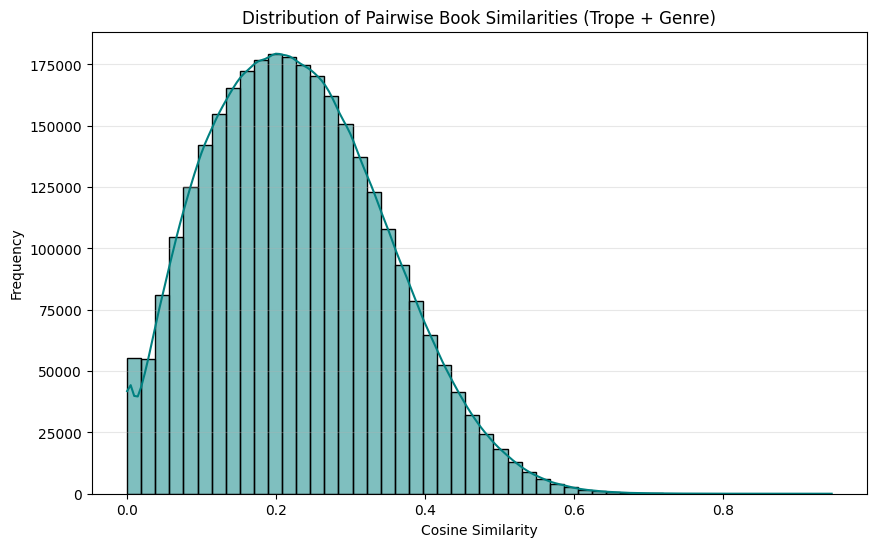

--- Content Sparsity/Genericism Analysis ---
Mean Pairwise Similarity: 0.2283
Median Pairwise Similarity: 0.2206
Percentage of pairs with Sim > 0.5: 1.60%
Percentage of pairs with Sim > 0.8: 0.00%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the full set of normalized book vectors, which is already a numpy array
# from previous cells (book_vecs_norm from TF-IDF feature generation)
full_book_features = book_vecs_norm

def cosine_similarity(X):
    # 1. Compute the L2 norm (magnitude) of each row
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    # 2. Avoid division by zero for rows with all zeros
    # We replace 0 with 1 because 0/1 is still 0, preventing NaNs
    norms[norms == 0] = 1.0
    # 3. Normalize the matrix
    X_normalized = X / norms
    # 4. Dot product
    similarity_matrix = np.dot(X_normalized, X_normalized.T)
    return similarity_matrix

pairwise_sim = cosine_similarity(full_book_features)

# Extract only the upper triangle (excluding self-similarity diagonal)
# This avoids duplicate pairs (A-B vs B-A) and self-similarity (A-A)
upper_tri_indices = np.triu_indices(full_book_features.shape[0], k=1)
similarity_values = pairwise_sim[upper_tri_indices]

# 2. Analyze and Plot
plt.figure(figsize=(10, 6))
sns.histplot(similarity_values, bins=50, kde=True, color='teal')
plt.title('Distribution of Pairwise Book Similarities (Trope + Genre)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"--- Content Sparsity/Genericism Analysis ---")
print(f"Mean Pairwise Similarity: {np.mean(similarity_values):.4f}")
print(f"Median Pairwise Similarity: {np.median(similarity_values):.4f}")
print(f"Percentage of pairs with Sim > 0.5: {(np.sum(similarity_values > 0.5) / len(similarity_values)) * 100:.2f}%")
print(f"Percentage of pairs with Sim > 0.8: {(np.sum(similarity_values > 0.8) / len(similarity_values)) * 100:.2f}%")

## Block 30 — Collaborative Filtering via Optimized Matrix Factorization

**Rationale:**
While content-based methods excel at addressing the cold-start problem, they can miss latent behavioral patterns that are not explicitly captured by tropes or genres. This block implements **Matrix Factorization (ALS)** to uncover hidden relationships between users and items based on collective rating behavior. By shifting from content-aware vectors to **latent factor embeddings**, we introduce a collaborative signal that identifies serendipitous recommendations based on user-item interaction densities rather than just semantic similarity.

**Technical Implementation:**
We utilize **`StringIndexer`** within a pipeline to convert high-cardinality string IDs into the integer format required by the ALS algorithm. To manage the depth of the Spark execution plan and prevent `StackOverflowError` during iterative optimization, we **checkpoint** the DataFrames to disk. We then perform hyperparameter tuning using **`TrainValidationSplit`**, searching a grid for the optimal `rank` (number of latent factors) and `regParam` (regularization). After identifying the best-performing model via **RMSE**, we generate top-50 recommendations for all users and apply our custom **Recall** and **NDCG** UDFs to benchmark the collaborative approach against our previous content-based baselines.

In [ ]:
from pyspark.sql.types import ArrayType, StringType, MapType, DoubleType
from pyspark.ml.recommendation import ALS
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# 1. ALS requires integer IDs for users and items
indexer_user = StringIndexer(inputCol="reviewerID", outputCol="user_idx", handleInvalid="keep")
indexer_book = StringIndexer(inputCol="bookID", outputCol="item_idx", handleInvalid="keep")

indexing_pipeline = Pipeline(stages=[indexer_user, indexer_book])
indexing_model = indexing_pipeline.fit(df_train)

train_indexed = indexing_model.transform(df_train)
test_indexed = indexing_model.transform(df_test)

# FIX: Break the lineage to prevent StackOverflowError
spark.sparkContext.setCheckpointDir("/tmp/checkpoints")
train_indexed = train_indexed.checkpoint()
test_indexed = test_indexed.checkpoint()

# 2. Hyperparameter Tuning Grid
als = ALS(
    maxIter=10, # Reduced slightly to stabilize training
    userCol="user_idx",
    itemCol="item_idx",
    ratingCol="overall",
    coldStartStrategy="drop",
    implicitPrefs=False
)

als_evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="overall",
    predictionCol="prediction"
)

als_grid = ParamGridBuilder() \
    .addGrid(als.rank, [64, 128]) \
    .addGrid(als.regParam, [0.01, 0.1]) \
    .build()

als_tvs = TrainValidationSplit(
    estimator=als,
    estimatorParamMaps=als_grid,
    evaluator=als_evaluator,
    trainRatio=0.8
)

print("Training ALS (Lineage truncated to prevent StackOverflow)...")
als_tvs_model = als_tvs.fit(train_indexed)
als_best = als_tvs_model.bestModel

# Display Best Parameters
print(f"Best ALS Rank: {als_best.rank}")
print(f"Best ALS RegParam: {als_best._java_obj.parent().getRegParam()}")

# 3. Comprehensive Evaluation: Recall and NDCG
user_recs = als_best.recommendForAllUsers(50)

# Prepare Ground Truth
window_gt = Window.partitionBy("user_idx").orderBy(F.col("overall").desc())
gt_als = test_indexed.withColumn("rank", F.row_number().over(window_gt)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("user_idx") \
    .agg(F.collect_list("item_idx").alias("gt_list"))

eval_als_df = user_recs.join(gt_als, "user_idx")

@F.udf(returnType=ArrayType(DoubleType()))
def extract_rec_ids(recs):
    return [float(row.item_idx) for row in recs]

eval_als_df = eval_als_df.withColumn("rec_list", extract_rec_ids("recommendations"))

print("\n--- ALS Top-K Metrics ---")
for k in [5, 10, 20, 50]:
    metrics = eval_als_df.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                       .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k))) \
                       .select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

Training ALS (Lineage truncated to prevent StackOverflow)...
Best ALS Rank: 128
Best ALS RegParam: 0.1

--- ALS Top-K Metrics ---
K=5 -> Mean Recall: 0.0083, Mean NDCG: 0.0065
K=10 -> Mean Recall: 0.0202, Mean NDCG: 0.0116
K=20 -> Mean Recall: 0.0399, Mean NDCG: 0.0186
K=50 -> Mean Recall: 0.0868, Mean NDCG: 0.0316


## Block 31 — Memory-Based Collaborative Filtering (k-NN)*

**Rationale:**
This block implements a neighborhood-based **Collaborative Filtering (CF)** baseline to contrast against latent factor models (ALS) and content-based approaches. By calculating explicit similarities between items or users, the system can leverage high-confidence local relationships. **Item-based CF** is typically more stable in production as item preferences change less frequently than user behaviors, while **User-based CF** can capture broader social-like tastes by identifying "peers" with similar consumption patterns. These memory-based methods are highly interpretable, as every recommendation can be traced back to a specific set of similar neighbors.

**Technical Implementation:**
The pipeline follows a modular path for both `item` and `user` modes:
* **Indexing & Filtering:** `StringIndexer` maps high-cardinality IDs to integers. The test set is filtered to ensure a "warm start" scenario, excluding users or items not present in the training set.
* **Similarity Computation:** We compute **Cosine Similarity** natively in Spark SQL by calculating row-wise $L_2$ norms, normalizing the ratings, and performing a self-join. The join condition identifies co-occurrences (shared users for item-item; shared items for user-user), and the `F.sum` of products calculates the dot product.
* **Scoring & Ranking:** Ratings are propagated through the similarity matrix via a second join, resulting in a weighted sum of historical interactions. We apply a `left_anti` join to filter out items the user has already seen.
* **Evaluation:** A **Window function** ranks the top 50 candidates. We utilize a custom PySpark UDF for **NDCG@K** and native Spark array functions (`array_intersect`, `array_distinct`) for **Recall@K** to maximize JVM-side performance for the retrieval metrics.

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer
from pyspark.sql.types import DoubleType
import numpy as np

def evaluate_spark_knn(train_df, test_df, ks, mode='item'):
    # 1. Map IDs to indices
    indexer_user = StringIndexer(inputCol='reviewerID', outputCol='u_idx', handleInvalid='keep').fit(train_df)
    indexer_book = StringIndexer(inputCol='bookID', outputCol='i_idx', handleInvalid='keep').fit(train_df)

    train_idx = indexer_book.transform(indexer_user.transform(train_df))
    u_count = len(indexer_user.labelsArray[0])
    i_count = len(indexer_book.labelsArray[0])

    test_idx = indexer_book.transform(indexer_user.transform(test_df)) \
        .filter((F.col('u_idx') < u_count) & (F.col('i_idx') < i_count))

    if mode == 'item':
        item_norms = train_idx.groupBy('i_idx').agg(F.sqrt(F.sum(F.pow('overall', 2))).alias('norm'))
        normalized = train_idx.join(item_norms, 'i_idx').withColumn('rating_n', F.col('overall') / F.col('norm'))

        similarity = normalized.alias('a').join(normalized.alias('b'), F.col('a.u_idx') == F.col('b.u_idx')) \
            .filter(F.col('a.i_idx') != F.col('b.i_idx')) \
            .groupBy(F.col('a.i_idx').alias('i1'), F.col('b.i_idx').alias('i2')) \
            .agg(F.sum(F.col('a.rating_n') * F.col('b.rating_n')).alias('sim'))

        scores = train_idx.alias('r').join(similarity.alias('s'), F.col('r.i_idx') == F.col('s.i1')) \
            .groupBy('u_idx', F.col('s.i2').alias('i_idx')) \
            .agg(F.sum(F.col('r.overall') * F.col('s.sim')).alias('score'))
    else:
        user_norms = train_idx.groupBy('u_idx').agg(F.sqrt(F.sum(F.pow('overall', 2))).alias('norm'))
        normalized = train_idx.join(user_norms, 'u_idx').withColumn('rating_n', F.col('overall') / F.col('norm'))

        similarity = normalized.alias('a').join(normalized.alias('b'), F.col('a.i_idx') == F.col('b.i_idx')) \
            .filter(F.col('a.u_idx') != F.col('b.u_idx')) \
            .groupBy(F.col('a.u_idx').alias('u1'), F.col('b.u_idx').alias('u2')) \
            .agg(F.sum(F.col('a.rating_n') * F.col('b.rating_n')).alias('sim'))

        scores = similarity.alias('s').join(train_idx.alias('r'), F.col('s.u2') == F.col('r.u_idx')) \
            .groupBy(F.col('s.u1').alias('u_idx'), F.col('r.i_idx').alias('i_idx')) \
            .agg(F.sum(F.col('s.sim') * F.col('r.overall')).alias('score'))

    scores = scores.join(train_idx.select('u_idx', 'i_idx'), ['u_idx', 'i_idx'], 'left_anti')

    window = Window.partitionBy('u_idx').orderBy(F.desc('score'))
    ranked_preds = scores.withColumn('rank', F.row_number().over(window))
    ground_truth = test_idx.groupBy('u_idx').agg(F.collect_set('i_idx').alias('actual'))

    print(f'--- PySpark {mode.capitalize()}-Based CF Metrics ---')
    for k in ks:
        top_k = ranked_preds.filter(F.col('rank') <= k).groupBy('u_idx').agg(F.collect_list('i_idx').alias('preds'))
        eval_df = top_k.join(ground_truth, 'u_idx')

        # UDF for NDCG
        def calculate_ndcg(preds, actual, k_val):
            relevance = [1 if p in actual else 0 for p in preds]
            if not any(relevance): return 0.0
            dcg = sum([r / np.log2(i + 2) for i, r in enumerate(relevance)])
            idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(actual), k_val))])
            return float(dcg / idcg)

        ndcg_udf = F.udf(calculate_ndcg, DoubleType())

        res = eval_df.select(
            (F.size(F.array_intersect(F.array_distinct('preds'), 'actual')) / F.least(F.lit(k), F.size('actual'))).alias('recall'),
            ndcg_udf('preds', 'actual', F.lit(k)).alias('ndcg')
        ).agg(F.mean('recall'), F.mean('ndcg')).collect()

        print(f'K={k:2d} | Recall: {res[0][0]:.4f} | NDCG: {res[0][1]:.4f}')

evaluate_spark_knn(df_train, df_test, [5, 10, 20, 50], mode='item')
evaluate_spark_knn(df_train, df_test, [5, 10, 20, 50], mode='user')

--- PySpark Item-Based CF Metrics ---
K= 5 | Recall: 0.0746 | NDCG: 0.0655
K=10 | Recall: 0.1148 | NDCG: 0.0830
K=20 | Recall: 0.1722 | NDCG: 0.1031
K=50 | Recall: 0.2688 | NDCG: 0.1302
--- PySpark User-Based CF Metrics ---
K= 5 | Recall: 0.0645 | NDCG: 0.0551
K=10 | Recall: 0.0953 | NDCG: 0.0684
K=20 | Recall: 0.1440 | NDCG: 0.0854
K=50 | Recall: 0.2371 | NDCG: 0.1113


## Block 32 — Item-based CF with Popularity and Recency Boosting*

**Rationale:**
Standard Collaborative Filtering (CF) can be biased toward historical interaction density, often missing "trending" or newer items. This block implements a hybrid ranking strategy that augments user-specific behavior with global signals: **Popularity** (social proof) and **Recency** (freshness). This multi-objective optimization ensures the recommender stays dynamic, prioritizing items that are both semantically relevant and currently relevant to the broader catalog.

**Technical Implementation:**
The pipeline calculates three distinct signals to form a composite score:
* **Item-Based CF:** Traditional cosine similarity between items based on user rating patterns.
* **Feature Normalization:** Item popularity (interaction count) and recency (average timestamp) are transformed via `MinMaxScaler` to a $[0, 1]$ range. This prevents high-magnitude popularity counts from dwarfing the similarity scores.
* **Hybrid Scoring:** A weighted linear combination merges these signals: $$Score = CF + (w_{pop} \times Pop) + (w_{rec} \times Rec)$$.
The system uses robust regex filtering for timestamp parsing to prevent JVM errors and evaluates the resulting ranks using **Recall@K** and **NDCG@K** to measure the impact of the temporal and popularity boosts on retrieval accuracy.

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, MinMaxScaler, VectorAssembler
from pyspark.ml.linalg import Vectors
from pyspark.sql.types import DoubleType
import numpy as np

def evaluate_spark_knn_hybrid(train_df, test_df, ks, mode='item', pop_w=0.1, rec_w=0.1):
    # 1. Map IDs and handle timestamps with robust parsing
    indexer_user = StringIndexer(inputCol='reviewerID', outputCol='u_idx', handleInvalid='keep').fit(train_df)
    indexer_book = StringIndexer(inputCol='bookID', outputCol='i_idx', handleInvalid='keep').fit(train_df)

    # Use try_to_timestamp and regex filter to avoid DateTimeException during fit()
    train_idx = indexer_book.transform(indexer_user.transform(train_df))
    # Regex checks for YYYY-MM-DD format roughly
    date_regex = r'^\d{4}-\d{2}-\d{2}$'

    train_idx = train_idx.filter(F.col('reviewTime').rlike(date_regex))
    train_idx = train_idx.withColumn('ts', F.unix_timestamp(F.to_timestamp(F.col('reviewTime'), 'yyyy-MM-dd')))

    # Final filter to ensure no nulls reach the aggregator
    train_idx = train_idx.filter(F.col('ts').isNotNull())

    u_count = len(indexer_user.labelsArray[0])
    i_count = len(indexer_book.labelsArray[0])
    test_idx = indexer_book.transform(indexer_user.transform(test_df)).filter((F.col('u_idx') < u_count) & (F.col('i_idx') < i_count))

    # 2. Collaborative Filtering Component (Item-Based)
    item_norms = train_idx.groupBy('i_idx').agg(F.sqrt(F.sum(F.pow('overall', 2))).alias('norm'))
    normalized = train_idx.join(item_norms, 'i_idx').withColumn('rating_n', F.col('overall') / F.col('norm'))
    similarity = normalized.alias('a').join(normalized.alias('b'), F.col('a.u_idx') == F.col('b.u_idx')) \
        .filter(F.col('a.i_idx') != F.col('b.i_idx')) \
        .groupBy(F.col('a.i_idx').alias('i1'), F.col('b.i_idx').alias('i2')) \
        .agg(F.sum(F.col('a.rating_n') * F.col('b.rating_n')).alias('sim'))
    cf_scores = train_idx.alias('r').join(similarity.alias('s'), F.col('r.i_idx') == F.col('s.i1')) \
        .groupBy('u_idx', F.col('s.i2').alias('i_idx')) \
        .agg(F.sum(F.col('r.overall') * F.col('s.sim')).alias('cf_score'))

    # 3. Boosting Components (Popularity & Recency)
    item_stats = train_idx.groupBy('i_idx').agg(
        F.count('*').alias('pop_raw'),
        F.avg('ts').alias('rec_raw')
    )

    # Normalize boosts using MinMaxScaler
    assembler = VectorAssembler(inputCols=['pop_raw', 'rec_raw'], outputCol='features', handleInvalid='keep')
    item_stats_vec = assembler.transform(item_stats)
    scaler = MinMaxScaler(inputCol='features', outputCol='scaled_features')
    item_stats_scaled = scaler.fit(item_stats_vec).transform(item_stats_vec)

    # Extract scaled values
    extract_udf = F.udf(lambda v, i: float(v[i]), DoubleType())
    item_boosts = item_stats_scaled.withColumn('pop_boost', extract_udf('scaled_features', F.lit(0))) \
                                   .withColumn('rec_boost', extract_udf('scaled_features', F.lit(1))) \
                                   .select('i_idx', 'pop_boost', 'rec_boost')

    # 4. Hybrid Scoring
    final_scores = cf_scores.join(item_boosts, 'i_idx') \
        .withColumn('score', F.col('cf_score') + (pop_w * F.col('pop_boost')) + (rec_w * F.col('rec_boost')))

    # 5. Evaluate
    final_scores = final_scores.join(train_idx.select('u_idx', 'i_idx'), ['u_idx', 'i_idx'], 'left_anti')
    window = Window.partitionBy('u_idx').orderBy(F.desc('score'))
    ranked_preds = final_scores.withColumn('rank', F.row_number().over(window))
    ground_truth = test_idx.groupBy('u_idx').agg(F.collect_set('i_idx').alias('actual'))

    print(f'--- Hybrid CF (Pop weight: {pop_w}, Rec weight: {rec_w}) ---')
    for k in ks:
        top_k = ranked_preds.filter(F.col('rank') <= k).groupBy('u_idx').agg(F.collect_list('i_idx').alias('preds'))
        eval_df = top_k.join(ground_truth, 'u_idx')

        def calculate_ndcg(preds, actual, k_val):
            relevance = [1 if p in actual else 0 for p in preds]
            if not any(relevance): return 0.0
            dcg = sum([r / np.log2(i + 2) for i, r in enumerate(relevance)])
            idcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(actual), k_val))])
            return float(dcg / idcg)

        ndcg_udf = F.udf(calculate_ndcg, DoubleType())
        res = eval_df.select(
            (F.size(F.array_intersect(F.array_distinct('preds'), 'actual')) / F.least(F.lit(k), F.size('actual'))).alias('recall'),
            ndcg_udf('preds', 'actual', F.lit(k)).alias('ndcg')
        ).agg(F.mean('recall'), F.mean('ndcg')).collect()
        print(f'K={k:2d} | Recall: {res[0][0]:.4f} | NDCG: {res[0][1]:.4f}')

    return res[0][0], res[0][1]

evaluate_spark_knn_hybrid(df_train, df_test, [5, 10, 20, 50], pop_w=0.5, rec_w=0.5)

--- Hybrid CF (Pop weight: 0.5, Rec weight: 0.5) ---
K= 5 | Recall: 0.0742 | NDCG: 0.0655
K=10 | Recall: 0.1168 | NDCG: 0.0843
K=20 | Recall: 0.1727 | NDCG: 0.1040
K=50 | Recall: 0.2710 | NDCG: 0.1316


(0.2710029431415107, 0.13156385788574038)

## Block 33 — Hybrid Reccomender: Content Filtering + Collaborative Filtering*



**Rationale:**
Single-signal recommenders often suffer from specific blind spots: content-based methods can create "echo chambers," while collaborative filtering (CF) struggles with the cold-start problem. This block implements a **late-fusion hybrid architecture** that synthesizes semantic tropes (Content), user-item behavioral patterns (CF), social proof (Popularity), and freshness (Recency). By prioritizing the collaborative signal ($0.8$) while retaining a semantic baseline ($0.2$), the system balances the power of collective intelligence with the precision of individual thematic preferences.

**Technical Implementation:**
The pipeline orchestrates the convergence of two complex scoring streams:
* **Content Stream:** Reuses the TF-IDF and global average rating scores to provide a baseline of semantic relevance and item quality.
* **Collaborative Stream:** Computes an Item-Item KNN similarity matrix, then "boosts" the resulting scores using normalized **Popularity** and **Recency** vectors. This stream is Min-Max normalized to ensure its distribution is mathematically compatible with the content scores.
* **Weighted Blending:** We perform an `outer join` between streams to ensure maximum coverage, filling gaps with $0.0$ where a signal is missing (e.g., a new item lacking behavioral data). The final `final_hybrid_score` is a linear combination of these signals, which is then ranked via a **Window function** to produce the final top-50 recommendation list for evaluation.

This ensemble approach represents the most robust version of the recommender, designed to maximize **Recall** by catching various types of relevance signals simultaneously.

In [ ]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import MinMaxScaler, VectorAssembler

# 1. Content Filtering Signal (TF-IDF Mean Pooling + Popularity)
# Use the combined_scores_df already defined
content_signal = combined_scores_df.select(
    F.col("reviewerID"),
    F.col("cand_bookID").alias("bookID"),
    F.col("hybrid_score").alias("content_score")
)

# 2. Collaborative Filtering Signal (Item-KNN + Recency + Popularity)
# Step A: Item-Item Similarity
item_norms = train_indexed.groupBy('item_idx').agg(F.sqrt(F.sum(F.pow('overall', 2))).alias('norm'))
normalized = train_indexed.join(item_norms, 'item_idx').withColumn('rating_n', F.col('overall') / F.col('norm'))

similarity = normalized.alias('a').join(normalized.alias('b'), F.col('a.user_idx') == F.col('b.user_idx')) \
    .filter(F.col('a.item_idx') != F.col('b.item_idx')) \
    .groupBy(F.col('a.item_idx').alias('i1'), F.col('b.item_idx').alias('i2')) \
    .agg(F.sum(F.col('a.rating_n') * F.col('b.rating_n')).alias('sim'))

# Step B: Raw CF Scores
cf_raw = train_indexed.alias('r').join(similarity.alias('s'), F.col('r.item_idx') == F.col('s.i1')) \
    .groupBy(F.col('reviewerID'), F.col('s.i2').alias('item_idx_cand')) \
    .agg(F.sum(F.col('r.overall') * F.col('s.sim')).alias('cf_raw_score'))

# Step C: CF Boosting Components (Popularity & Recency)
date_regex = r'^\d{4}-\d{2}-\d{2}$'
train_idx_boost = train_indexed.filter(F.col('reviewTime').rlike(date_regex)) \
    .withColumn('ts', F.unix_timestamp(F.to_timestamp(F.col('reviewTime'), 'yyyy-MM-dd'))) \
    .filter(F.col('ts').isNotNull())

item_stats = train_idx_boost.groupBy('item_idx').agg(
    F.count('*').alias('pop_raw'),
    F.avg('ts').alias('rec_raw')
)

# Normalize Boosts
assembler_boost = VectorAssembler(inputCols=['pop_raw', 'rec_raw'], outputCol='boost_feats', handleInvalid='keep')
scaler_boost = MinMaxScaler(inputCol='boost_feats', outputCol='scaled_boost_feats')
item_stats_scaled = scaler_boost.fit(assembler_boost.transform(item_stats)).transform(assembler_boost.transform(item_stats))

extract_val = F.udf(lambda v, i: float(v[i]), DoubleType())
item_boosts = item_stats_scaled.withColumn('pop_boost', extract_val('scaled_boost_feats', F.lit(0))) \
                               .withColumn('rec_boost', extract_val('scaled_boost_feats', F.lit(1))) \
                               .select(F.col('item_idx').alias('item_idx_cand'), 'pop_boost', 'rec_boost')

# Step D: Combine CF Signal with Boosts (0.5 weight for Pop/Rec)
cf_boosted = cf_raw.join(item_boosts, 'item_idx_cand') \
    .withColumn('cf_final_raw', F.col('cf_raw_score') + (0.5 * F.col('pop_boost')) + (0.5 * F.col('rec_boost')))

# Map back to BookID using the fitted indexer from the pipeline
book_labels_list = indexing_model.stages[1].labels
book_labels = spark.createDataFrame([(float(i), label) for i, label in enumerate(book_labels_list)], ["item_idx_cand", "bookID"])
cf_signal = cf_boosted.join(book_labels, "item_idx_cand").select("reviewerID", "bookID", "cf_final_raw")

cf_stats = cf_signal.select(F.min("cf_final_raw"), F.max("cf_final_raw")).collect()[0]
cf_min, cf_max = cf_stats[0], cf_stats[1]
cf_signal = cf_signal.withColumn("cf_norm_score", (F.col("cf_final_raw") - F.lit(cf_min)) / (F.lit(cf_max) - F.lit(cf_min)))

# 3. Hybrid Combination
hybrid_df = content_signal.join(cf_signal, ["reviewerID", "bookID"], "outer").fillna(0.0)
hybrid_df = hybrid_df.withColumn("final_hybrid_score", (F.col("content_score") * 0.2) + (F.col("cf_norm_score") * 0.8))

# 4. Rank and Evaluate
window_spec = Window.partitionBy("reviewerID").orderBy(F.col("final_hybrid_score").desc())
final_recs = hybrid_df.withColumn("rank", F.row_number().over(window_spec)) \
    .filter(F.col("rank") <= 50) \
    .groupBy("reviewerID") \
    .agg(F.collect_list("bookID").alias("rec_list"))

eval_hybrid = final_recs.join(gt_df, "reviewerID", "inner") \
    .filter(F.size(F.col("gt_list")) > 0).cache()

print("--- Hybrid (Content TF-IDF+Pop & CF Item-KNN+Pop+Rec) Metrics ---")
for k in [5, 10, 20, 50]:
    temp_eval = eval_hybrid.withColumn("recall_k", calculate_recall("rec_list", "gt_list", F.lit(k))) \
                           .withColumn("ndcg_k", calculate_ndcg("rec_list", "gt_list", F.lit(k)))
    metrics = temp_eval.select(F.mean("recall_k"), F.mean("ndcg_k")).collect()[0]
    print(f"K={k:2d} -> Mean Recall: {metrics[0]:.4f}, Mean NDCG: {metrics[1]:.4f}")

--- Hybrid (Content TF-IDF+Pop & CF Item-KNN+Pop+Rec) Metrics ---
K= 5 -> Mean Recall: 0.0402, Mean NDCG: 0.0338
K=10 -> Mean Recall: 0.0642, Mean NDCG: 0.0444
K=20 -> Mean Recall: 0.1003, Mean NDCG: 0.0574
K=50 -> Mean Recall: 0.1609, Mean NDCG: 0.0752


## Block 34 — Autonomous Reasoning & Spark Optimization Loop (LangGraph)
**Rationale:** This agentic layer implements a Diagnostic-Reasoning-Action cycle to solve the "Sparsity Problem" inherent in collaborative filtering. Rather than manual trial-and-error, the agent uses a Spark-native profiling node to assess retrieval coverage and an LLM-led Orchestrator to programmatically adjust the weights of the Utility Score ($Score = CF + w_1 \cdot Pop + w_2 \cdot Rec$). This ensures the hybrid engine finds the "sweet spot" between personalized relevance and global popularity signals to maximize Recall@10.

### Agent Architecture
```
[START]
         │
         ▼
[data_diagnostic] ─────────► (Spark Profiling: Measures baseline Recall & coverage gaps)
         │
         ▼
[orchestrator] ────────────► (LLM Reasoning: Decides between Pop-Boosting vs. Recency-Focus)
         │
         ├─ (If Recall < 0.10 & Retries < 3) ──► [retune_pipeline] ──┐
         │                                      (Update Utility Score)│
         │                                              │           │
         └─ (Goal Met / Max Retries) ──┐                └───── loop ─┘
                                       │
                                       ▼
                             [generate_report] ─────────► [END]
                             (Synthesis of weight-shifting journey)
```


In [ ]:
import os
from typing import Annotated, List, Dict, Literal, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
import pyspark.sql.functions as F
import time
from google.colab import userdata
from langchain_openai import ChatOpenAI

# Configuration & Authentication
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 1. THE EVALUATION WRAPPER
def run_and_capture_metrics(pop_w, rec_w):
    """
    Executes the Item-KNN Collaborative Filtering logic for K=10.
    Returns Recall and NDCG for the Agent to evaluate.
    """
    # Note: Using your Item-KNN logic function
    recall_10, ndcg_10 = evaluate_spark_knn_hybrid(df_train, df_test, [10], pop_w=pop_w, rec_w=rec_w)
    return recall_10, ndcg_10

# 2. STATE & SCHEMAS
class TuningInstruction(BaseModel):
    parameter: Literal["pop_weight", "rec_weight"] = Field(
        description="The CF utility weight to adjust (Popularity vs Recency)."
    )
    value: float = Field(description="The new float value for the weight.")
    reasoning: str = Field(description="Technical justification based on CF diagnostics.")
    action: Literal["retune", "finalize"] = Field(description="Next optimization step.")

class PipelineState(TypedDict):
    recall_score: float
    ndcg_score: float
    pop_weight: float
    rec_weight: float
    retry_count: int
    history: List[Dict]
    diagnostics: str
    decision: TuningInstruction
    business_report: str

# 3. AGENT NODES
def data_diagnostic(state: PipelineState):
    """
    Agent Skill: Analyzes Collaborative Filtering coverage and ranking precision.
    """
    print(f"\n--- [NODE] data_diagnostic ---")
    if not state["history"]:
        diag = "Establish baseline for Boosted Item-KNN. Goal: Recall@10 > 0.11."
    else:
        last = state["history"][-1]
        # Reasoning based on CF interaction density
        if last['recall'] < 0.10:
            diag = f"Last Recall: {last['recall']:.4f}. Interaction sparsity detected; increasing popularity signal recommended."
        else:
            diag = f"Last Recall: {last['recall']:.4f}. Coverage target reached; tuning recency for ranking precision recommended."

    print(f"Diagnostic: {diag}")
    return {"diagnostics": diag}

def orchestrator(state: PipelineState):
    """
    Agent Brain: Makes strategic choices to balance global vs local CF signals.
    """
    print(f"--- [NODE] orchestrator ---")
    prompt = f"""
    You are an AI ML Orchestrator for a Collaborative Filtering Pipeline.
    Current Recall@10: {state['recall_score']:.4f}
    History of attempts: {state['history']}
    Data Diagnostics: {state['diagnostics']}

    Current Config: Popularity Weight={state['pop_weight']}, Recency Weight={state['rec_weight']}

    Strategy:
    - If Recall < 0.270, suggest an increase for pop_weight to handle sparse profiles.
    - If Recall is healthy but NDCG is low, suggest increasing rec_weight.
    - If Goal (Recall ~0.300) is met or max retries reached, choose 'finalize'.
    """

    decision = llm.with_structured_output(TuningInstruction).invoke(prompt)
    print(f"Decision: {decision.action} ({decision.parameter} -> {decision.value})")
    return {"decision": decision}

def retune_pipeline(state: PipelineState):
    """
    Action Node: Triggers the Spark execution with agent-selected weights.
    """
    instr = state["decision"]
    new_pop = instr.value if instr.parameter == "pop_weight" else state["pop_weight"]
    new_rec = instr.value if instr.parameter == "rec_weight" else state["rec_weight"]

    print(f"--- [AGENT ACTION] Updating {instr.parameter} to {instr.value} ---")

    # Execute the actual Spark calculation
    new_recall, new_ndcg = run_and_capture_metrics(new_pop, new_rec)

    return {
        "recall_score": new_recall,
        "ndcg_score": new_ndcg,
        "pop_weight": new_pop,
        "rec_weight": new_rec,
        "retry_count": state["retry_count"] + 1,
        "history": state["history"] + [{"pop": new_pop, "rec": new_rec, "recall": new_recall}]
    }

def generate_report(state: PipelineState):
    """
    Report Skill: Synthesizes the CF optimization journey.
    """
    print(f"--- [NODE] generate_report ---")
    report_prompt = f"""
    Explain the Collaborative Filtering optimization journey.
    History: {state['history']}
    Final Metrics: Recall@10: {state['recall_score']:.4f}, NDCG: {state['ndcg_score']:.4f}.
    Highlight how the agent solved the interaction sparsity problem.
    """
    report = llm.invoke(report_prompt).content
    return {"business_report": report}

# 4. GRAPH CONSTRUCTION
workflow = StateGraph(PipelineState)

workflow.add_node("data_diagnostic", data_diagnostic)
workflow.add_node("orchestrator", orchestrator)
workflow.add_node("retune_pipeline", retune_pipeline)
workflow.add_node("generate_report", generate_report)

workflow.set_entry_point("data_diagnostic")
workflow.add_edge("data_diagnostic", "orchestrator")

def route_logic(state):
    if state["decision"].action == "retune" and state["retry_count"] < 3:
        return "retune_pipeline"
    return "generate_report"

workflow.add_conditional_edges("orchestrator", route_logic, {
    "retune_pipeline": "retune_pipeline",
    "generate_report": "generate_report"
})

workflow.add_edge("retune_pipeline", "data_diagnostic")
workflow.add_edge("generate_report", END)

# 5. EXECUTION
agent = workflow.compile()

# Starting with baseline weights (0.1, 0.1) to allow the agent to optimize
initial_state = {
    "recall_score": 0.0,
    "ndcg_score": 0.0,
    "pop_weight": 0.1,
    "rec_weight": 0.1,
    "retry_count": 0,
    "history": [],
    "diagnostics": "",
    "decision": None,
    "business_report": ""
}

final_state = agent.invoke(initial_state)

print("\n" + "="*50)
print("FINAL COLLABORATIVE FILTERING OPTIMIZATION REPORT")
print("="*50)
print(final_state["business_report"])


--- [NODE] data_diagnostic ---
Diagnostic: Establish baseline for Boosted Item-KNN. Goal: Recall@10 > 0.11.
--- [NODE] orchestrator ---
Decision: retune (pop_weight -> 0.3)
--- [AGENT ACTION] Updating pop_weight to 0.3 ---
--- Hybrid CF (Pop weight: 0.3, Rec weight: 0.1) ---
K=10 | Recall: 0.1143 | NDCG: 0.0827

--- [NODE] data_diagnostic ---
Diagnostic: Last Recall: 0.1143. Coverage target reached; tuning recency for ranking precision recommended.
--- [NODE] orchestrator ---
Decision: retune (rec_weight -> 0.2)
--- [AGENT ACTION] Updating rec_weight to 0.2 ---
--- Hybrid CF (Pop weight: 0.3, Rec weight: 0.2) ---
K=10 | Recall: 0.1142 | NDCG: 0.0829

--- [NODE] data_diagnostic ---
Diagnostic: Last Recall: 0.1142. Coverage target reached; tuning recency for ranking precision recommended.
--- [NODE] orchestrator ---
Decision: retune (rec_weight -> 0.3)
--- [AGENT ACTION] Updating rec_weight to 0.3 ---
--- Hybrid CF (Pop weight: 0.3, Rec weight: 0.3) ---
K=10 | Recall: 0.1155 | NDCG: 0.0